### Exploratary Data Analysis

In [3]:
# load necessary python packages
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
# file path
DATA_DIR = Path("output")
REPORT_DIR = Path("eda_reports")
CHART_DIR = REPORT_DIR / "charts"

REPORT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

SOLD_FILE = DATA_DIR / "combined_sold.csv"
LIST_FILE = DATA_DIR / "combined_list.csv"

sold = pd.read_csv(SOLD_FILE, low_memory=False)
listed = pd.read_csv(LIST_FILE, low_memory=False)


### Helper Functions

In [53]:
def print_section(title):
    print("\n" + "-" * 80)
    print(title)
    print("-" * 80)


def clean_numeric(series):
    """
    Convert messy numeric fields into numeric values.
    Handles strings with commas or dollar signs.
    """
    return (
        series
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
        .pipe(pd.to_numeric, errors="coerce")
    )


def normalize_year_month(df):
    """
    Make sure year_month is stored as a clean string like 202401.
    """
    if "year_month" in df.columns:
        df["year_month"] = (
            df["year_month"]
            .astype(str)
            .str.replace(".0", "", regex=False)
            .str.strip()
        )
    return df


def structure_summary(df, dataset_name):
    """
    Review row count, column count, data types, missing count,
    missing percent, and unique count.
    """
    print_section(f"{dataset_name} Structure Summary")

    print(f"{dataset_name} rows:", df.shape[0])
    print(f"{dataset_name} columns:", df.shape[1])

    report = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str),
        "non_null_count": df.notna().sum().values,
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "unique_count": df.nunique(dropna=True).values
    })

    report = report.sort_values("missing_percent", ascending=False)

    output_path = REPORT_DIR / f"{dataset_name}_structure_summary.csv"
    report.to_csv(output_path, index=False)

    print(report.to_string(index=False))

    return report


def check_time_range(df, dataset_name):
    """
    Check whether year_month covers 202401 to 202605.
    """
    print_section(f"{dataset_name} Time Range Check")

    if "year_month" not in df.columns:
        print("year_month column not found.")
        return None

    month_counts = (
        df["year_month"]
        .value_counts(dropna=False)
        .sort_index()
        .reset_index()
    )

    month_counts.columns = ["year_month", "row_count"]

    print(f"{dataset_name} year_month min:", df["year_month"].min())
    print(f"{dataset_name} year_month max:", df["year_month"].max())

    expected_months = pd.period_range(
        start="2024-01",
        end="2026-05",
        freq="M"
    ).strftime("%Y%m").tolist()

    actual_months = sorted(df["year_month"].dropna().unique().tolist())
    missing_months = sorted(set(expected_months) - set(actual_months))
    extra_months = sorted(set(actual_months) - set(expected_months))

    print("Expected range: 202401 to 202605")
    print("Missing months:", missing_months)
    print("Extra months outside expected range:", extra_months)

    output_path = REPORT_DIR / f"{dataset_name}_month_counts.csv"
    month_counts.to_csv(output_path, index=False)

    return month_counts


def property_type_report(df, dataset_name):
    """
    Review unique PropertyType values and property type share.
    Should use full unfiltered data for this part.
    """
    print_section(f"{dataset_name} PropertyType Review")

    if "PropertyType" not in df.columns:
        print("PropertyType column not found.")
        return None

    counts = df["PropertyType"].value_counts(dropna=False)
    percents = (df["PropertyType"].value_counts(normalize=True, dropna=False) * 100).round(2)

    report = pd.DataFrame({
        "property_type": counts.index.astype(str),
        "count": counts.values,
        "percent": percents.values
    })

    output_path = REPORT_DIR / f"{dataset_name}_property_type_report.csv"
    report.to_csv(output_path, index=False)

    print(report.to_string(index=False))

    return report


def filter_residential(df, dataset_name):
    """
    Filter PropertyType == Residential.
    """
    print_section(f"{dataset_name} Residential Filter")

    if "PropertyType" not in df.columns:
        print("PropertyType column not found. Returning original dataframe.")
        return df.copy()

    residential_df = df[df["PropertyType"] == "Residential"].copy()

    print(f"{dataset_name} original rows:", df.shape[0])
    print(f"{dataset_name} residential rows:", residential_df.shape[0])
    print(
        f"{dataset_name} residential share:",
        round(residential_df.shape[0] / df.shape[0] * 100, 2),
        "%"
    )

    output_path = REPORT_DIR / f"{dataset_name}_residential_filtered.csv"
    residential_df.to_csv(output_path, index=False)

    return residential_df


def missing_value_report(df, dataset_name):
    """
    Calculate missing counts and percentages.
    Flag columns with more than 90% missing values.
    """
    print_section(f"{dataset_name} Missing Value Report")

    report = pd.DataFrame({
        "column": df.columns,
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "non_null_count": df.notna().sum().values,
        "unique_count": df.nunique(dropna=True).values
    })

    report["above_90_missing"] = report["missing_percent"] > 90
    report = report.sort_values("missing_percent", ascending=False)

    output_path = REPORT_DIR / f"{dataset_name}_missing_value_report.csv"
    report.to_csv(output_path, index=False)

    high_missing = report[report["above_90_missing"] == True]
    high_missing_path = REPORT_DIR / f"{dataset_name}_above_90_missing_columns.csv"
    high_missing.to_csv(high_missing_path, index=False)

    print("Top 20 missing columns:")
    print(report.head(20).to_string(index=False))

    print("\nColumns above 90% missing:")
    if high_missing.empty:
        print("No columns above 90% missing.")
    else:
        print(high_missing.to_string(index=False))

    return report


def classify_fields(df, dataset_name):
    """
    Separate columns into:
    1. market_analysis_field
    2. optional_market_field
    3. metadata_field
    4. duplicate_column
    5. needs_manual_review
    """

    print_section(f"{dataset_name} Field Classification")

    market_analysis_fields = {
        # Price fields
        "ClosePrice",
        "ListPrice",
        "OriginalListPrice",

        # Time fields
        "CloseDate",
        "ListingContractDate",
        "PurchaseContractDate",
        "ContractStatusChangeDate",
        "year_month",
        "DaysOnMarket",

        # Status / property category
        "MlsStatus",
        "PropertyType",
        "PropertySubType",

        # Location fields
        "City",
        "CountyOrParish",
        "StateOrProvince",
        "PostalCode",
        "MLSAreaMajor",
        "Latitude",
        "Longitude",

        # Size / area fields
        "LivingArea",
        "BuildingAreaTotal",
        "AboveGradeFinishedArea",
        "BelowGradeFinishedArea",
        "LotSizeAcres",
        "LotSizeSquareFeet",
        "LotSizeArea",

        # Property characteristics
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "BathroomsFull",
        "BathroomsHalf",
        "YearBuilt",
        "Stories",
        "Levels",
        "MainLevelBedrooms",

        # Parking / garage
        "GarageSpaces",
        "ParkingTotal",
        "CoveredSpaces",
        "AttachedGarageYN",

        # Amenities / features
        "FireplaceYN",
        "FireplacesTotal",
        "BasementYN",
        "PoolPrivateYN",
        "WaterfrontYN",
        "ViewYN",
        "NewConstructionYN",

        # Cost / fee
        "AssociationFee",
        "TaxAnnualAmount"
    }

    optional_market_fields = {
        # School fields
        "ElementarySchool",
        "ElementarySchoolDistrict",
        "MiddleOrJuniorSchool",
        "MiddleOrJuniorSchoolDistrict",
        "HighSchool",
        "HighSchoolDistrict",

        # Neighborhood / subdivision
        "SubdivisionName",

        # HOA / tax details
        "AssociationFeeFrequency",
        "TaxYear",

        # Property details
        "Flooring",
        "LotSizeDimensions",
        "BuilderName",

        # Compensation fields
        "BuyerAgencyCompensation",
        "BuyerAgencyCompensationType"
    }

    metadata_fields = {
        # Source tracking
        "source_file",
        "data_type",
        "file_version",
        "OriginatingSystemName",
        "OriginatingSystemSubName",

        # Listing identifiers
        "ListingId",
        "ListingKey",
        "ListingKeyNumeric",

        # Address-level detail
        "StreetNumberNumeric",
        "UnparsedAddress",

        # Agent fields
        "ListAgentFirstName",
        "ListAgentLastName",
        "ListAgentFullName",
        "ListAgentEmail",
        "ListAgentAOR",
        "ListAgentKey",
        "ListAgentMlsId",

        "BuyerAgentFirstName",
        "BuyerAgentLastName",
        "BuyerAgentMlsId",
        "BuyerAgentAOR",
        "BuyerAgentKey",

        "CoBuyerAgentFirstName",
        "CoListAgentFirstName",
        "CoListAgentLastName",

        # Office fields
        "ListOfficeName",
        "CoListOfficeName",
        "BuyerOfficeName",
        "BuyerOfficeAOR",
        "ListOfficeKey",
        "BuyerOfficeKey",

        # System timestamps
        "ModificationTimestamp",
        "OriginalEntryTimestamp",

        # Other non-market fields
        "BusinessType",
        "latfilled",
        "lonfilled"
    }

    records = []

    for col in df.columns:
        lower_col = col.lower()

        if col.endswith(".1"):
            category = "duplicate_column"
        elif col in market_analysis_fields:
            category = "market_analysis_field"
        elif col in optional_market_fields:
            category = "optional_market_field"
        elif col in metadata_fields:
            category = "metadata_field"
        elif any(word in lower_col for word in [
            "price", "bed", "bath", "area", "lot", "county",
            "city", "dom", "date", "fee", "tax", "garage",
            "parking", "school", "subdivision"
        ]):
            category = "possible_market_analysis_field"
        elif any(word in lower_col for word in [
            "id", "key", "source", "system", "agent",
            "office", "timestamp", "mlsid", "email"
        ]):
            category = "possible_metadata_field"
        else:
            category = "needs_manual_review"

        records.append({
            "column": col,
            "dtype": str(df[col].dtype),
            "category": category
        })

    report = pd.DataFrame(records)

    output_path = REPORT_DIR / f"{dataset_name}_field_classification.csv"
    report.to_csv(output_path, index=False)

    print(report["category"].value_counts().to_string())
    print(f"Saved field classification report to: {output_path}")

    return report


# Print columns by category
def print_columns_by_category(report, dataset_name):
    print_section(f"{dataset_name} Columns by Category")

    categories = report["category"].unique()

    for category in categories:
        cols = report.loc[report["category"] == category, "column"].tolist()

        print("\n" + "-" * 50)
        print(f"{category}: {len(cols)} columns")
        print("-" * 50)

        for col in cols:
            print(col)


def numeric_distribution_summary(df, dataset_name, numeric_fields):
    """
    Generate min, max, mean, median, and percentile summaries.
    """
    print_section(f"{dataset_name} Numeric Distribution Summary")

    available_fields = [col for col in numeric_fields if col in df.columns]

    if not available_fields:
        print("No numeric fields found.")
        return None

    numeric_df = pd.DataFrame()

    for col in available_fields:
        numeric_df[col] = clean_numeric(df[col])

    summary = numeric_df.describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    ).T

    summary = summary.rename(columns={
        "50%": "median"
    })

    output_path = REPORT_DIR / f"{dataset_name}_numeric_distribution_summary.csv"
    summary.to_csv(output_path)

    print(summary.to_string())

    return summary


def numeric_outlier_summary(df, dataset_name, numeric_fields):
    """
    Identify potential extreme outliers using the IQR rule.
    This does not delete anything. It only flags potential issues.
    """
    print_section(f"{dataset_name} Numeric Outlier Summary")

    records = []

    for col in numeric_fields:
        if col not in df.columns:
            continue

        series = clean_numeric(df[col]).dropna()

        if series.empty:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        low_outliers = (series < lower_bound).sum()
        high_outliers = (series > upper_bound).sum()

        records.append({
            "column": col,
            "non_null_count": series.count(),
            "min": series.min(),
            "q1": q1,
            "median": series.median(),
            "q3": q3,
            "max": series.max(),
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "low_outlier_count": low_outliers,
            "high_outlier_count": high_outliers,
            "total_outlier_count": low_outliers + high_outliers,
            "outlier_percent": round((low_outliers + high_outliers) / series.count() * 100, 2)
        })

    report = pd.DataFrame(records)

    output_path = REPORT_DIR / f"{dataset_name}_numeric_outlier_summary.csv"
    report.to_csv(output_path, index=False)

    if report.empty:
        print("No numeric outlier summary generated.")
    else:
        print(report.to_string(index=False))

    return report


def save_and_show(output_path, show_plots=False):
    """
    Save chart and optionally show it.
    """
    plt.savefig(output_path)
    if show_plots:
        plt.show()
    plt.close()

def save_and_show(output_path, show_plots=False):
    """
    Save chart and optionally show it.
    """
    plt.savefig(output_path)

    if show_plots:
        plt.show()

    plt.close()


def create_numeric_charts(df, dataset_name, numeric_fields, show_plots=False):
    """
    Generate EDA charts based on numeric variable type.

    Discrete count fields:
    - BedroomsTotal
    - BathroomsTotalInteger
    - BathroomsFull
    - BathroomsHalf

    These get:
    1. Bar chart with 10+ bucket
    2. Boxplot

    DaysOnMarket:
    1. Clipped histogram
    2. Bucket bar chart
    3. Boxplot

    Continuous numeric fields:
    1. Raw histogram
    2. Clipped histogram using 1st to 99th percentile
    3. Boxplot

    Any numeric field not listed will be treated as continuous numeric.
    """

    print_section(f"{dataset_name} Numeric Charts")

    # --------------------------------------------------
    # Column type groups
    # --------------------------------------------------

    discrete_count_fields = [
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "BathroomsFull",
        "BathroomsHalf"
    ]

    continuous_fields = [
        "ClosePrice",
        "ListPrice",
        "OriginalListPrice",
        "LivingArea",
        "BuildingAreaTotal",
        "LotSizeAcres",
        "LotSizeSquareFeet",
        "YearBuilt"
    ]

    for col in numeric_fields:
        if col not in df.columns:
            print(f"{col} not found. Skipped.")
            continue

        series = clean_numeric(df[col]).dropna()

        if series.empty:
            print(f"{col} has no valid numeric values. Skipped.")
            continue

        # --------------------------------------------------
        # 1. Bedrooms / Bathrooms
        # --------------------------------------------------

        if col in discrete_count_fields:
            print(f"Creating discrete count charts for {col}")

            # Group extreme values into 10+
            bucketed = series.apply(lambda x: "10+" if x >= 10 else str(int(x)))

            counts = bucketed.value_counts()

            # Sort labels: 0, 1, 2, ..., 10+
            sorted_index = sorted(
                counts.index,
                key=lambda x: 10 if x == "10+" else int(x)
            )

            counts = counts.reindex(sorted_index)

            count_report = pd.DataFrame({
                col: counts.index,
                "count": counts.values,
                "percent": (counts.values / counts.sum() * 100).round(2)
            })

            count_report.to_csv(
                REPORT_DIR / f"{dataset_name}_{col}_distribution_report.csv",
                index=False
            )

            # Bar chart
            plt.figure(figsize=(8, 5))
            counts.plot(kind="bar")
            plt.title(f"{dataset_name} - {col} Distribution")
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.xticks(rotation=0)
            plt.tight_layout()

            save_and_show(
                CHART_DIR / f"{dataset_name}_{col}_bar_chart.png",
                show_plots
            )

            # Boxplot
            plt.figure(figsize=(8, 5))
            plt.boxplot(series, vert=False)
            plt.title(f"{dataset_name} - {col} Boxplot")
            plt.xlabel(col)
            plt.tight_layout()

            save_and_show(
                CHART_DIR / f"{dataset_name}_{col}_boxplot.png",
                show_plots
            )

            continue

        # --------------------------------------------------
        # 2. DaysOnMarket
        # --------------------------------------------------

        if col == "DaysOnMarket":
            print("Creating DaysOnMarket charts")

            lower = series.quantile(0.01)
            upper = series.quantile(0.99)
            clipped = series[(series >= lower) & (series <= upper)]

            # Clipped histogram
            if not clipped.empty and lower < upper:
                plt.figure(figsize=(8, 5))
                plt.hist(clipped, bins=50)
                plt.title(f"{dataset_name} - DaysOnMarket Clipped Histogram")
                plt.xlabel(f"DaysOnMarket ({lower:,.0f} to {upper:,.0f})")
                plt.ylabel("Frequency")
                plt.tight_layout()

                save_and_show(
                    CHART_DIR / f"{dataset_name}_DaysOnMarket_clipped_histogram.png",
                    show_plots
                )

            # Bucket bar chart
            bins = [-1, 7, 14, 30, 60, 90, 180, np.inf]
            labels = [
                "0-7 days",
                "8-14 days",
                "15-30 days",
                "31-60 days",
                "61-90 days",
                "91-180 days",
                "180+ days"
            ]

            dom_bucket = pd.cut(series, bins=bins, labels=labels)
            bucket_counts = dom_bucket.value_counts().reindex(labels)

            bucket_report = pd.DataFrame({
                "DOM_bucket": bucket_counts.index,
                "count": bucket_counts.values,
                "percent": (bucket_counts.values / bucket_counts.sum() * 100).round(2)
            })

            bucket_report.to_csv(
                REPORT_DIR / f"{dataset_name}_DaysOnMarket_bucket_report.csv",
                index=False
            )

            plt.figure(figsize=(9, 5))
            bucket_counts.plot(kind="bar")
            plt.title(f"{dataset_name} - DaysOnMarket Bucket Distribution")
            plt.xlabel("Days on Market Bucket")
            plt.ylabel("Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()

            save_and_show(
                CHART_DIR / f"{dataset_name}_DaysOnMarket_bucket_bar_chart.png",
                show_plots
            )

            # Boxplot
            plt.figure(figsize=(8, 5))
            plt.boxplot(series, vert=False)
            plt.title(f"{dataset_name} - DaysOnMarket Boxplot")
            plt.xlabel("DaysOnMarket")
            plt.tight_layout()

            save_and_show(
                CHART_DIR / f"{dataset_name}_DaysOnMarket_boxplot.png",
                show_plots
            )

            continue

        # --------------------------------------------------
        # 3. Continuous numeric fields
        # --------------------------------------------------

        print(f"Creating continuous numeric charts for {col}")

        # Raw histogram
        plt.figure(figsize=(8, 5))
        plt.hist(series, bins=50)
        plt.title(f"{dataset_name} - {col} Raw Histogram")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.tight_layout()

        save_and_show(
            CHART_DIR / f"{dataset_name}_{col}_raw_histogram.png",
            show_plots
        )

        # Clipped histogram: 1st percentile to 99th percentile
        lower = series.quantile(0.01)
        upper = series.quantile(0.99)
        clipped = series[(series >= lower) & (series <= upper)]

        if not clipped.empty and lower < upper:
            plt.figure(figsize=(8, 5))
            plt.hist(clipped, bins=50)
            plt.title(f"{dataset_name} - {col} Clipped Histogram")
            plt.xlabel(f"{col} ({lower:,.2f} to {upper:,.2f})")
            plt.ylabel("Frequency")
            plt.tight_layout()

            save_and_show(
                CHART_DIR / f"{dataset_name}_{col}_clipped_histogram.png",
                show_plots
            )

        # Boxplot
        plt.figure(figsize=(8, 5))
        plt.boxplot(series, vert=False)
        plt.title(f"{dataset_name} - {col} Boxplot")
        plt.xlabel(col)
        plt.tight_layout()

        save_and_show(
            CHART_DIR / f"{dataset_name}_{col}_boxplot.png",
            show_plots
        )

    print("Charts saved to:", CHART_DIR)


def create_property_type_distribution(df, dataset_name, show_plots=False):
    """
    Create PropertyType distribution table and charts.
    Use full unfiltered dataset.
    """

    print_section(f"{dataset_name} PropertyType Distribution")

    if "PropertyType" not in df.columns:
        print("PropertyType column not found.")
        return None

    temp = df.copy()
    temp["PropertyType"] = temp["PropertyType"].fillna("Missing")

    counts = temp["PropertyType"].value_counts(dropna=False)
    percents = (
        temp["PropertyType"]
        .value_counts(normalize=True, dropna=False) * 100
    ).round(2)

    report = pd.DataFrame({
        "PropertyType": counts.index,
        "Count": counts.values,
        "Percent": percents.values
    })

    report.to_csv(
        REPORT_DIR / f"{dataset_name}_property_type_distribution.csv",
        index=False
    )

    print(report.to_string(index=False))

    # --------------------------------------------------
    # Bar chart
    # --------------------------------------------------

    plt.figure(figsize=(10, 6))
    counts.plot(kind="bar")
    plt.title(f"{dataset_name} PropertyType Distribution")
    plt.xlabel("PropertyType")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    save_and_show(
        CHART_DIR / f"{dataset_name}_property_type_distribution_bar_chart.png",
        show_plots
    )

    # --------------------------------------------------
    # Pie chart
    # --------------------------------------------------

    plt.figure(figsize=(8, 8))
    counts.plot(kind="pie", autopct="%1.1f%%")
    plt.title(f"{dataset_name} PropertyType Distribution")
    plt.ylabel("")
    plt.tight_layout()

    save_and_show(
        CHART_DIR / f"{dataset_name}_property_type_distribution_pie_chart.png",
        show_plots
    )

    print("Saved property type distribution table and charts.")

    return report


def create_property_type_distribution(df, dataset_name):
    """
    Create PropertyType distribution table and charts.
    Use full unfiltered dataset.
    """

    print_section(f"{dataset_name} PropertyType Distribution")

    if "PropertyType" not in df.columns:
        print("PropertyType column not found.")
        return None

    # Fill missing values so NaN can also be counted
    temp = df.copy()
    temp["PropertyType"] = temp["PropertyType"].fillna("Missing")

    # Count and percent
    counts = temp["PropertyType"].value_counts(dropna=False)
    percents = (temp["PropertyType"].value_counts(normalize=True, dropna=False) * 100).round(2)

    report = pd.DataFrame({
        "PropertyType": counts.index,
        "Count": counts.values,
        "Percent": percents.values
    })

    # Save table
    report.to_csv(REPORT_DIR / f"{dataset_name}_property_type_distribution.csv", index=False)

    print(report.to_string(index=False))

    # -----------------------------
    # Bar chart
    # -----------------------------
    plt.figure(figsize=(10, 6))
    counts.plot(kind="bar")
    plt.title(f"{dataset_name} PropertyType Distribution")
    plt.xlabel("PropertyType")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(CHART_DIR / f"{dataset_name}_property_type_distribution_bar_chart.png")
    plt.show()
    plt.close()

    # -----------------------------
    # Pie chart
    # -----------------------------
    plt.figure(figsize=(8, 8))
    counts.plot(kind="pie", autopct="%1.1f%%")
    plt.title(f"{dataset_name} PropertyType Distribution")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(CHART_DIR / f"{dataset_name}_property_type_distribution_pie_chart.png")
    plt.show()
    plt.close()

    print("Saved property type distribution table and charts.")

    return report


def answer_suggested_questions(sold_full, sold_residential):
    """
    Answer suggested EDA questions using Sold data.
    PropertyType share uses full data.
    Market analysis questions use residential data.
    """
    print_section("Suggested EDA Questions")

    question_results = {}

    # Q1: Residential vs other property type share
    if "PropertyType" in sold_full.columns:
        residential_count = (sold_full["PropertyType"] == "Residential").sum()
        total_count = sold_full.shape[0]
        residential_share = round(residential_count / total_count * 100, 2)

        question_results["residential_count"] = residential_count
        question_results["total_sold_count"] = total_count
        question_results["residential_share_percent"] = residential_share

        print(f"Residential share in Sold data: {residential_share}%")

    # Q2: Median and average ClosePrice
    if "ClosePrice" in sold_residential.columns:
        close_price = clean_numeric(sold_residential["ClosePrice"])

        question_results["median_close_price"] = close_price.median()
        question_results["average_close_price"] = close_price.mean()

        print(f"Median ClosePrice: {close_price.median():,.2f}")
        print(f"Average ClosePrice: {close_price.mean():,.2f}")

    # Q3: Days on Market distribution
    if "DaysOnMarket" in sold_residential.columns:
        dom = clean_numeric(sold_residential["DaysOnMarket"])

        dom_summary = dom.describe(
            percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
        )

        dom_summary.to_csv(REPORT_DIR / "sold_residential_days_on_market_summary.csv")

        print("\nDays on Market distribution:")
        print(dom_summary.to_string())

    # Q4: Sold above vs below list price
    if {"ClosePrice", "ListPrice"}.issubset(sold_residential.columns):
        price_df = sold_residential.copy()
        price_df["ClosePrice_num"] = clean_numeric(price_df["ClosePrice"])
        price_df["ListPrice_num"] = clean_numeric(price_df["ListPrice"])

        price_df = price_df.dropna(subset=["ClosePrice_num", "ListPrice_num"])

        price_df["sale_vs_list"] = np.select(
            [
                price_df["ClosePrice_num"] > price_df["ListPrice_num"],
                price_df["ClosePrice_num"] < price_df["ListPrice_num"],
                price_df["ClosePrice_num"] == price_df["ListPrice_num"]
            ],
            [
                "sold_above_list",
                "sold_below_list",
                "sold_at_list"
            ],
            default="unknown"
        )

        sale_vs_list_report = pd.DataFrame({
            "count": price_df["sale_vs_list"].value_counts(),
            "percent": (price_df["sale_vs_list"].value_counts(normalize=True) * 100).round(2)
        })

        sale_vs_list_report.to_csv(REPORT_DIR / "sold_residential_sale_vs_list_report.csv")

        print("\nSold above vs below list price:")
        print(sale_vs_list_report.to_string())

    # Q5: Date consistency issue
    possible_list_date_cols = [
        "ListDate",
        "OnMarketDate",
        "OriginalEntryTimestamp"
    ]

    possible_close_date_cols = [
        "CloseDate",
        "PurchaseContractDate"
    ]

    list_date_col = next(
        (col for col in possible_list_date_cols if col in sold_residential.columns),
        None
    )

    close_date_col = next(
        (col for col in possible_close_date_cols if col in sold_residential.columns),
        None
    )

    if list_date_col and close_date_col:
        date_df = sold_residential.copy()

        date_df[list_date_col] = pd.to_datetime(date_df[list_date_col], errors="coerce")
        date_df[close_date_col] = pd.to_datetime(date_df[close_date_col], errors="coerce")

        date_issues = date_df[
            date_df[close_date_col] < date_df[list_date_col]
        ].copy()

        date_issues.to_csv(
            REPORT_DIR / "sold_residential_close_before_list_date_issues.csv",
            index=False
        )

        print(f"\nDate consistency check using {list_date_col} and {close_date_col}:")
        print("Rows where close date is before list date:", date_issues.shape[0])

    else:
        print("\nDate consistency check skipped because date columns were not found.")

    # Q6: Counties with highest median prices
    if {"CountyOrParish", "ClosePrice"}.issubset(sold_residential.columns):
        county_df = sold_residential.copy()
        county_df["ClosePrice_num"] = clean_numeric(county_df["ClosePrice"])

        county_price_report = (
            county_df
            .dropna(subset=["CountyOrParish", "ClosePrice_num"])
            .groupby("CountyOrParish")
            .agg(
                row_count=("ClosePrice_num", "count"),
                median_close_price=("ClosePrice_num", "median"),
                average_close_price=("ClosePrice_num", "mean")
            )
            .sort_values("median_close_price", ascending=False)
        )

        county_price_report.to_csv(
            REPORT_DIR / "sold_residential_county_median_price_report.csv"
        )

        print("\nTop 10 counties by median ClosePrice:")
        print(county_price_report.head(10).to_string())

    result_df = pd.DataFrame([question_results])
    result_df.to_csv(REPORT_DIR / "sold_suggested_question_summary.csv", index=False)

    return result_df

# --------------------------------------------------
# Suggested EDA Question Charts
# --------------------------------------------------



def create_suggested_eda_question_charts(
    combined_sold,
    combined_list,
    combined_sold_residential,
    show_plots=False
):
    """
    Create charts and summary tables to answer the suggested EDA questions.

    Questions covered:
    1. What is the Residential vs. other property type share?
    2. What are the median and average close prices?
    3. What does the Days on Market distribution look like?
    4. What percentage of homes sold above vs. below list price?
    5. Are there date consistency issues?
    6. Which counties have the highest median prices?
    """

    print_section("Suggested EDA Question Charts")

    summary_notes = []

    def add_note(sentence):
        print("- " + sentence)
        summary_notes.append(sentence)

    # --------------------------------------------------
    # 1. PropertyType share
    # Use full unfiltered Sold and List datasets
    # --------------------------------------------------

    for df, dataset_name in [
        (combined_sold, "combined_sold"),
        (combined_list, "combined_list")
    ]:
        if "PropertyType" not in df.columns:
            print(f"{dataset_name}: PropertyType column not found.")
            continue

        temp = df.copy()
        temp["PropertyType"] = temp["PropertyType"].fillna("Missing")

        property_counts = temp["PropertyType"].value_counts(dropna=False)
        property_percent = (
            temp["PropertyType"].value_counts(normalize=True, dropna=False) * 100
        ).round(2)

        property_report = pd.DataFrame({
            "PropertyType": property_counts.index,
            "count": property_counts.values,
            "percent": property_percent.values
        })

        property_report.to_csv(
            REPORT_DIR / f"{dataset_name}_suggested_property_type_share.csv",
            index=False
        )

        plt.figure(figsize=(10, 6))
        property_counts.plot(kind="bar")
        plt.title(f"{dataset_name} PropertyType Distribution")
        plt.xlabel("PropertyType")
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()

        save_and_show(
            CHART_DIR / f"{dataset_name}_suggested_property_type_share_bar_chart.png",
            show_plots
        )

        residential_share = (
            temp["PropertyType"].eq("Residential").mean() * 100
        ).round(2)

        add_note(
            f"{dataset_name}: Residential properties represent {residential_share}% of the full dataset."
        )

    # --------------------------------------------------
    # 2. Average and median ClosePrice
    # Use Sold Residential dataset
    # --------------------------------------------------

    if "ClosePrice" in combined_sold_residential.columns:
        close_price = clean_numeric(
            combined_sold_residential["ClosePrice"]
        ).dropna()

        close_price_summary = pd.DataFrame({
            "metric": ["average_close_price", "median_close_price"],
            "value": [close_price.mean(), close_price.median()]
        })

        close_price_summary.to_csv(
            REPORT_DIR / "sold_residential_average_median_close_price.csv",
            index=False
        )

        plt.figure(figsize=(7, 5))
        plt.bar(
            close_price_summary["metric"],
            close_price_summary["value"]
        )
        plt.title("Sold Residential Average vs Median ClosePrice")
        plt.xlabel("Metric")
        plt.ylabel("ClosePrice")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()

        save_and_show(
            CHART_DIR / "sold_residential_average_median_close_price_bar_chart.png",
            show_plots
        )

        add_note(
            f"The median Sold Residential ClosePrice is ${close_price.median():,.0f}, "
            f"and the average ClosePrice is ${close_price.mean():,.0f}."
        )

    # --------------------------------------------------
    # 3. DaysOnMarket distribution
    # Use Sold Residential dataset
    # --------------------------------------------------

    if "DaysOnMarket" in combined_sold_residential.columns:
        dom = clean_numeric(
            combined_sold_residential["DaysOnMarket"]
        ).dropna()

        if not dom.empty:
            dom_summary = dom.describe(
                percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
            )

            dom_summary.to_csv(
                REPORT_DIR / "sold_residential_days_on_market_summary.csv"
            )

            lower = dom.quantile(0.01)
            upper = dom.quantile(0.99)
            dom_clipped = dom[(dom >= lower) & (dom <= upper)]

            plt.figure(figsize=(8, 5))
            plt.hist(dom_clipped, bins=50)
            plt.title("Sold Residential DaysOnMarket Distribution")
            plt.xlabel(f"DaysOnMarket ({lower:,.0f} to {upper:,.0f})")
            plt.ylabel("Frequency")
            plt.tight_layout()

            save_and_show(
                CHART_DIR / "sold_residential_days_on_market_clipped_histogram.png",
                show_plots
            )

            bins = [-1, 7, 14, 30, 60, 90, 180, np.inf]
            labels = [
                "0-7 days",
                "8-14 days",
                "15-30 days",
                "31-60 days",
                "61-90 days",
                "91-180 days",
                "180+ days"
            ]

            dom_bucket = pd.cut(dom, bins=bins, labels=labels)
            dom_bucket_counts = dom_bucket.value_counts().reindex(labels)

            dom_bucket_report = pd.DataFrame({
                "DOM_bucket": dom_bucket_counts.index,
                "count": dom_bucket_counts.values,
                "percent": (
                    dom_bucket_counts.values / dom_bucket_counts.sum() * 100
                ).round(2)
            })

            dom_bucket_report.to_csv(
                REPORT_DIR / "sold_residential_days_on_market_bucket_report.csv",
                index=False
            )

            plt.figure(figsize=(9, 5))
            dom_bucket_counts.plot(kind="bar")
            plt.title("Sold Residential DaysOnMarket Bucket Distribution")
            plt.xlabel("Days on Market Bucket")
            plt.ylabel("Count")
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()

            save_and_show(
                CHART_DIR / "sold_residential_days_on_market_bucket_bar_chart.png",
                show_plots
            )

            add_note(
                f"The median DaysOnMarket is {dom.median():,.0f} days, "
                f"and the 90th percentile is {dom.quantile(0.90):,.0f} days."
            )

    # --------------------------------------------------
    # 4. Sold above vs below list price
    # Use Sold Residential dataset
    # --------------------------------------------------

    if {"ClosePrice", "ListPrice"}.issubset(combined_sold_residential.columns):
        price_df = combined_sold_residential.copy()

        price_df["ClosePrice_num"] = clean_numeric(price_df["ClosePrice"])
        price_df["ListPrice_num"] = clean_numeric(price_df["ListPrice"])

        price_df = price_df.dropna(
            subset=["ClosePrice_num", "ListPrice_num"]
        )

        if not price_df.empty:
            price_df["sale_vs_list"] = np.select(
                [
                    price_df["ClosePrice_num"] > price_df["ListPrice_num"],
                    price_df["ClosePrice_num"] < price_df["ListPrice_num"],
                    price_df["ClosePrice_num"] == price_df["ListPrice_num"]
                ],
                [
                    "Sold above list",
                    "Sold below list",
                    "Sold at list"
                ],
                default="Unknown"
            )

            sale_vs_list_counts = price_df["sale_vs_list"].value_counts()
            sale_vs_list_percent = (
                price_df["sale_vs_list"].value_counts(normalize=True) * 100
            ).round(2)

            sale_vs_list_report = pd.DataFrame({
                "sale_vs_list": sale_vs_list_counts.index,
                "count": sale_vs_list_counts.values,
                "percent": sale_vs_list_percent.values
            })

            sale_vs_list_report.to_csv(
                REPORT_DIR / "sold_residential_sale_vs_list_report.csv",
                index=False
            )

            plt.figure(figsize=(8, 5))
            sale_vs_list_counts.plot(kind="bar")
            plt.title("Sold Residential Sale Price vs List Price")
            plt.xlabel("Sale vs List Category")
            plt.ylabel("Count")
            plt.xticks(rotation=20, ha="right")
            plt.tight_layout()

            save_and_show(
                CHART_DIR / "sold_residential_sale_vs_list_bar_chart.png",
                show_plots
            )

            above_percent = sale_vs_list_percent.get("Sold above list", 0)
            below_percent = sale_vs_list_percent.get("Sold below list", 0)
            at_percent = sale_vs_list_percent.get("Sold at list", 0)

            add_note(
                f"Among Sold Residential records with valid prices, "
                f"{above_percent:.2f}% sold above list price, "
                f"{below_percent:.2f}% sold below list price, and "
                f"{at_percent:.2f}% sold at list price."
            )

    # --------------------------------------------------
    # 5. Date consistency issues
    # Use Sold Residential dataset
    # --------------------------------------------------

    possible_list_date_cols = [
        "ListDate",
        "OnMarketDate",
        "OriginalEntryTimestamp"
    ]

    possible_close_date_cols = [
        "CloseDate",
        "PurchaseContractDate"
    ]

    list_date_col = next(
        (col for col in possible_list_date_cols if col in combined_sold_residential.columns),
        None
    )

    close_date_col = next(
        (col for col in possible_close_date_cols if col in combined_sold_residential.columns),
        None
    )

    if list_date_col and close_date_col:
        date_df = combined_sold_residential.copy()

        date_df[list_date_col] = pd.to_datetime(
            date_df[list_date_col],
            errors="coerce"
        )

        date_df[close_date_col] = pd.to_datetime(
            date_df[close_date_col],
            errors="coerce"
        )

        missing_dates = date_df[
            date_df[list_date_col].isna() | date_df[close_date_col].isna()
        ]

        valid_dates = date_df.dropna(
            subset=[list_date_col, close_date_col]
        )

        date_issues = valid_dates[
            valid_dates[close_date_col] < valid_dates[list_date_col]
        ]

        valid_order = valid_dates[
            valid_dates[close_date_col] >= valid_dates[list_date_col]
        ]

        date_issue_report = pd.DataFrame({
            "date_check_category": [
                "Valid date order",
                "Close date before list date",
                "Missing date information"
            ],
            "count": [
                valid_order.shape[0],
                date_issues.shape[0],
                missing_dates.shape[0]
            ]
        })

        date_issue_report["percent"] = (
            date_issue_report["count"] / date_df.shape[0] * 100
        ).round(2)

        date_issue_report.to_csv(
            REPORT_DIR / "sold_residential_date_consistency_report.csv",
            index=False
        )

        date_issues.to_csv(
            REPORT_DIR / "sold_residential_close_before_list_date_rows.csv",
            index=False
        )

        plt.figure(figsize=(8, 5))
        plt.bar(
            date_issue_report["date_check_category"],
            date_issue_report["count"]
        )
        plt.title("Sold Residential Date Consistency Check")
        plt.xlabel("Date Check Category")
        plt.ylabel("Count")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()

        save_and_show(
            CHART_DIR / "sold_residential_date_consistency_bar_chart.png",
            show_plots
        )

        add_note(
            f"Date consistency was checked using {list_date_col} and {close_date_col}. "
            f"There are {date_issues.shape[0]:,} records where the close date is before the list date."
        )

    else:
        add_note(
            "Date consistency chart was skipped because suitable list date and close date columns were not found."
        )

    # --------------------------------------------------
    # 6. County-level median ClosePrice
    # Use Sold Residential dataset
    # --------------------------------------------------

    if {"CountyOrParish", "ClosePrice"}.issubset(combined_sold_residential.columns):
        county_df = combined_sold_residential.copy()
        county_df["ClosePrice_num"] = clean_numeric(county_df["ClosePrice"])

        county_price_report = (
            county_df
            .dropna(subset=["CountyOrParish", "ClosePrice_num"])
            .groupby("CountyOrParish")
            .agg(
                row_count=("ClosePrice_num", "count"),
                median_close_price=("ClosePrice_num", "median"),
                average_close_price=("ClosePrice_num", "mean")
            )
            .sort_values("median_close_price", ascending=False)
        )

        county_price_report.to_csv(
            REPORT_DIR / "sold_residential_county_median_close_price_report.csv"
        )

        top_counties = county_price_report.head(10)

        plt.figure(figsize=(10, 6))
        top_counties["median_close_price"].plot(kind="bar")
        plt.title("Top 10 Counties by Median ClosePrice")
        plt.xlabel("County")
        plt.ylabel("Median ClosePrice")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()

        save_and_show(
            CHART_DIR / "sold_residential_top_10_counties_median_close_price_bar_chart.png",
            show_plots
        )

        if not top_counties.empty:
            top_county = top_counties.index[0]
            top_price = top_counties.iloc[0]["median_close_price"]

            add_note(
                f"{top_county} has the highest median ClosePrice among counties, "
                f"with a median of ${top_price:,.0f}."
            )

    # --------------------------------------------------
    # Save short analysis notes
    # --------------------------------------------------

    summary_notes_df = pd.DataFrame({
        "analysis_sentence": summary_notes
    })

    summary_notes_df.to_csv(
        REPORT_DIR / "suggested_eda_question_analysis_notes.csv",
        index=False
    )

    print("\nSuggested EDA question charts completed.")
    print("Charts saved to:", CHART_DIR)
    print("Summary notes saved to:")
    print(REPORT_DIR / "suggested_eda_question_analysis_notes.csv")

    return summary_notes_df

### Normalize year_month

In [11]:
combined_sold = normalize_year_month(sold)
combined_list = normalize_year_month(listed)

### Full Dataset Structure Review

In [33]:
sold_structure_report = structure_summary(combined_sold, "combined_sold")
list_structure_report = structure_summary(combined_list, "combined_list")


--------------------------------------------------------------------------------
combined_sold Structure Summary
--------------------------------------------------------------------------------
combined_sold rows: 639920
combined_sold columns: 88
                      column   dtype  non_null_count  missing_count  missing_percent  unique_count
MiddleOrJuniorSchoolDistrict float64               0         639920           100.00             0
      AboveGradeFinishedArea float64               0         639920           100.00             0
    ElementarySchoolDistrict float64               0         639920           100.00             0
             FireplacesTotal float64               0         639920           100.00             0
               CoveredSpaces float64               0         639920           100.00             0
                     TaxYear float64             394         639526            99.94            13
                WaterfrontYN  object             357       

### Dataset time range check

In [ ]:
# Use year_month directly
sold_month_counts = check_time_range(combined_sold, "combined_sold")
list_month_counts = check_time_range(combined_list, "combined_list")


--------------------------------------------------------------------------------
combined_sold Time Range Check
--------------------------------------------------------------------------------
combined_sold year_month min: 202401
combined_sold year_month max: 202605
Expected range: 202401 to 202605
Missing months: []
Extra months outside expected range: []

--------------------------------------------------------------------------------
combined_list Time Range Check
--------------------------------------------------------------------------------
combined_list year_month min: 202401
combined_list year_month max: 202605
Expected range: 202401 to 202605
Missing months: []
Extra months outside expected range: []


### 5. PropertyType review

In [54]:
# Use full unfiltered data
sold_property_report = property_type_report(combined_sold, "combined_sold")
list_property_report = property_type_report(combined_list, "combined_list")



--------------------------------------------------------------------------------
combined_sold PropertyType Review
--------------------------------------------------------------------------------
      property_type  count  percent
        Residential 430447    67.27
   ResidentialLease 146567    22.90
               Land  20727     3.24
 ManufacturedInPark  17325     2.71
  ResidentialIncome  17133     2.68
     CommercialSale   3981     0.62
    CommercialLease   3320     0.52
BusinessOpportunity    420     0.07

--------------------------------------------------------------------------------
combined_list PropertyType Review
--------------------------------------------------------------------------------
      property_type  count  percent
        Residential 591568    63.63
   ResidentialLease 192309    20.68
               Land  60598     6.52
  ResidentialIncome  34549     3.72
 ManufacturedInPark  26626     2.86
     CommercialSale  12714     1.37
    CommercialLease   8366    


--------------------------------------------------------------------------------
combined_sold PropertyType Distribution
--------------------------------------------------------------------------------
       PropertyType  Count  Percent
        Residential 430447    67.27
   ResidentialLease 146567    22.90
               Land  20727     3.24
 ManufacturedInPark  17325     2.71
  ResidentialIncome  17133     2.68
     CommercialSale   3981     0.62
    CommercialLease   3320     0.52
BusinessOpportunity    420     0.07


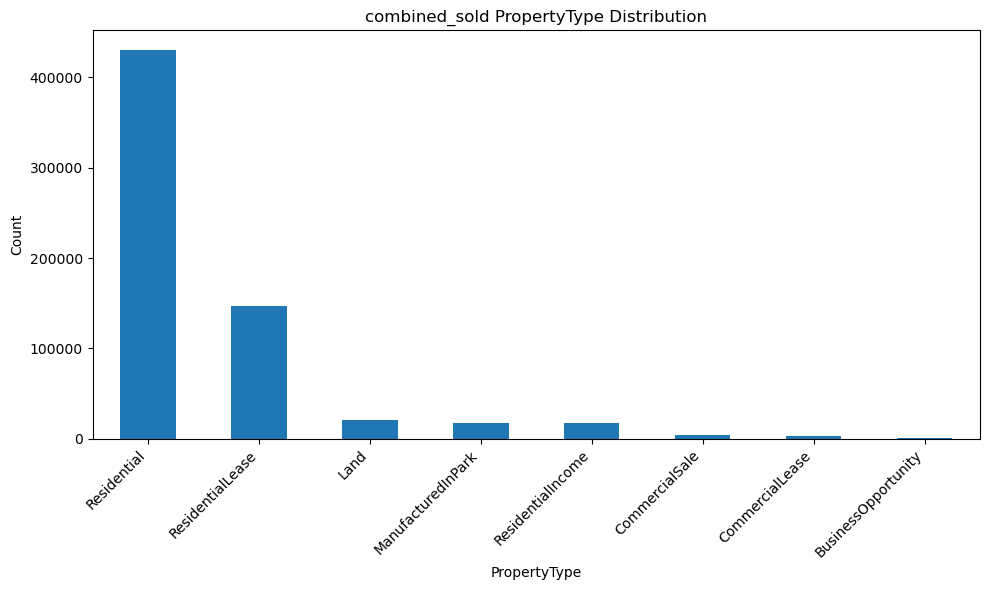

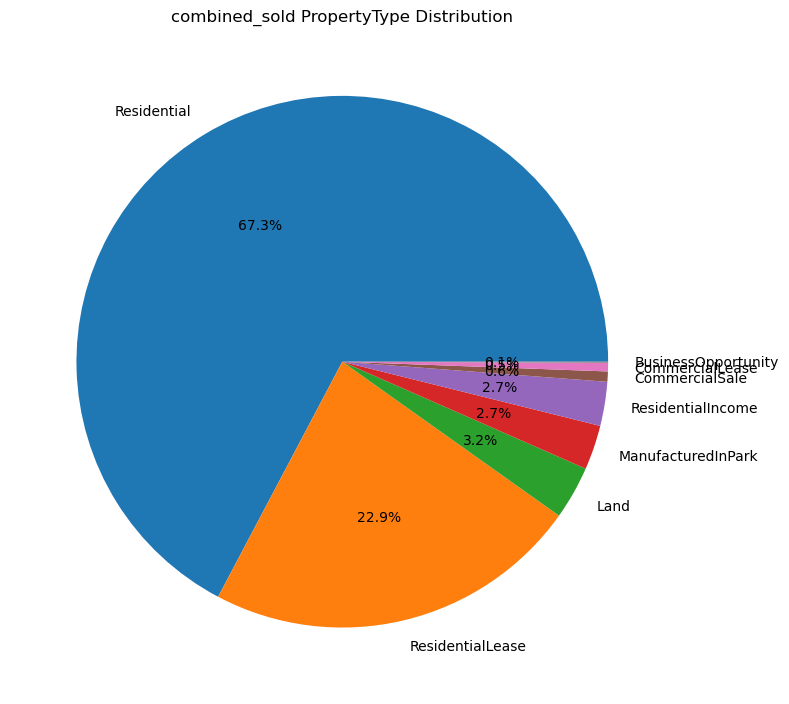

Saved property type distribution table and charts.

--------------------------------------------------------------------------------
combined_list PropertyType Distribution
--------------------------------------------------------------------------------
       PropertyType  Count  Percent
        Residential 591568    63.63
   ResidentialLease 192309    20.68
               Land  60598     6.52
  ResidentialIncome  34549     3.72
 ManufacturedInPark  26626     2.86
     CommercialSale  12714     1.37
    CommercialLease   8366     0.90
BusinessOpportunity   2979     0.32


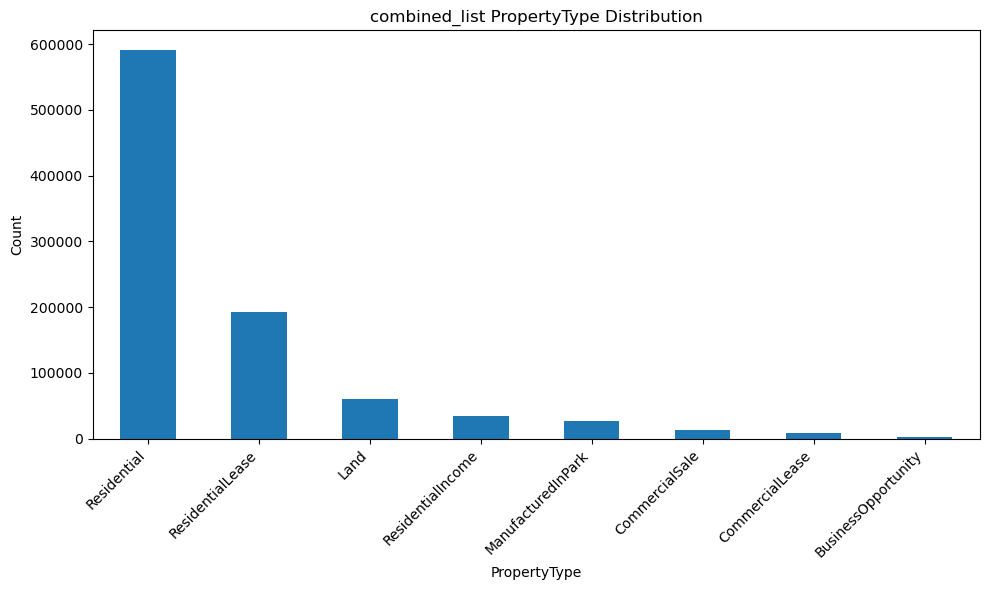

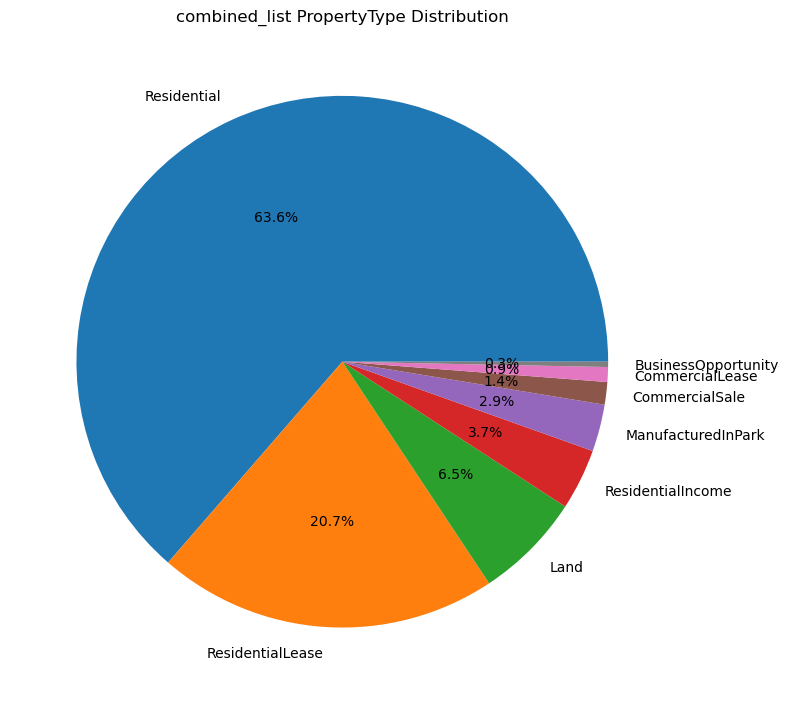

Saved property type distribution table and charts.


In [55]:
sold_property_distribution = create_property_type_distribution(
    combined_sold,
    "combined_sold"
)

list_property_distribution = create_property_type_distribution(
    combined_list,
    "combined_list"
)

### 6. Filter Residential

In [57]:
combined_sold_residential = filter_residential(combined_sold, "combined_sold")
combined_list_residential = filter_residential(combined_list, "combined_list")


--------------------------------------------------------------------------------
combined_sold Residential Filter
--------------------------------------------------------------------------------
combined_sold original rows: 639920
combined_sold residential rows: 430447
combined_sold residential share: 67.27 %

--------------------------------------------------------------------------------
combined_list Residential Filter
--------------------------------------------------------------------------------
combined_list original rows: 929709
combined_list residential rows: 591568
combined_list residential share: 63.63 %


### 7. Missing value analysis

In [ ]:
sold_missing_report = missing_value_report(
    combined_sold_residential,
    "combined_sold_residential"
)

list_missing_report = missing_value_report(
    combined_list_residential,
    "combined_list_residential"
)


--------------------------------------------------------------------------------
combined_sold_residential Missing Value Report
--------------------------------------------------------------------------------
Top 20 missing columns:
                      column  missing_count  missing_percent  non_null_count  unique_count  above_90_missing
               CoveredSpaces         430447           100.00               0             0              True
             TaxAnnualAmount         430447           100.00               0             0              True
    ElementarySchoolDistrict         430447           100.00               0             0              True
                BusinessType         430447           100.00               0             0              True
             FireplacesTotal         430447           100.00               0             0              True
                     TaxYear         430447           100.00               0             0              True
Mid

### 8. Separate market analysis fields from metadata fields

In [61]:
sold_field_report = classify_fields(
    combined_sold_residential,
    "combined_sold_residential"
)

list_field_report = classify_fields(
    combined_list_residential,
    "combined_list_residential"
)


--------------------------------------------------------------------------------
combined_sold_residential Field Classification
--------------------------------------------------------------------------------
category
market_analysis_field    45
metadata_field           29
optional_market_field    14
Saved field classification report to: eda_reports/combined_sold_residential_field_classification.csv

--------------------------------------------------------------------------------
combined_list_residential Field Classification
--------------------------------------------------------------------------------
category
market_analysis_field    41
metadata_field           23
optional_market_field    13
duplicate_column         11
Saved field classification report to: eda_reports/combined_list_residential_field_classification.csv


In [62]:
print_columns_by_category(
    sold_field_report,
    "combined_sold_residential"
)

print_columns_by_category(
    list_field_report,
    "combined_list_residential"
)


--------------------------------------------------------------------------------
combined_sold_residential Columns by Category
--------------------------------------------------------------------------------

--------------------------------------------------
metadata_field: 29 columns
--------------------------------------------------
BuyerAgentAOR
ListAgentAOR
ListingKey
ListAgentEmail
ListAgentFirstName
ListAgentLastName
UnparsedAddress
ListOfficeName
BuyerOfficeName
CoListOfficeName
ListAgentFullName
CoListAgentFirstName
CoListAgentLastName
BuyerAgentMlsId
BuyerAgentFirstName
BuyerAgentLastName
ListingKeyNumeric
BuyerOfficeAOR
StreetNumberNumeric
ListingId
CoBuyerAgentFirstName
BusinessType
OriginatingSystemName
OriginatingSystemSubName
source_file
data_type
file_version
latfilled
lonfilled

--------------------------------------------------
optional_market_field: 14 columns
--------------------------------------------------
Flooring
AssociationFeeFrequency
ElementarySchool
Builde

### 9. Numeric distribution review

In [64]:
numeric_fields = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "DaysOnMarket",
    "LivingArea",
    "BuildingAreaTotal",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt"
]


sold_numeric_summary = numeric_distribution_summary(
    combined_sold_residential,
    "combined_sold_residential",
    numeric_fields
)

list_numeric_summary = numeric_distribution_summary(
    combined_list_residential,
    "combined_list_residential",
    numeric_fields
)


--------------------------------------------------------------------------------
combined_sold_residential Numeric Distribution Summary
--------------------------------------------------------------------------------
                          count          mean           std     min         1%         5%        25%       median           75%         95%           99%           max
ClosePrice             430445.0  1.193113e+06  6.174107e+06     0.0  202000.00  340000.00  575000.00  825000.0000  1.300000e+06  2850000.00  5.575000e+06  9.895000e+08
ListPrice              430447.0  1.141744e+06  1.358097e+06   525.0  214900.00  345900.00  578000.00  819000.0000  1.295000e+06  2860000.00  5.700000e+06  1.375000e+08
OriginalListPrice      429658.0  1.226565e+06  6.686723e+06     0.0  210000.00  349900.00  585000.00  828000.0000  1.299000e+06  2900000.00  5.995000e+06  1.390000e+09
DaysOnMarket           430447.0  3.733444e+01  5.366977e+01  -288.0       0.00       1.00       8.00      18.0

### 10. Numeric outlier review

In [66]:
sold_outlier_summary = numeric_outlier_summary(
    combined_sold_residential,
    "combined_sold_residential",
    numeric_fields
)

list_outlier_summary = numeric_outlier_summary(
    combined_list_residential,
    "combined_list_residential",
    numeric_fields
)




--------------------------------------------------------------------------------
combined_sold_residential Numeric Outlier Summary
--------------------------------------------------------------------------------
               column  non_null_count    min        q1      median           q3          max         iqr  lower_bound  upper_bound  low_outlier_count  high_outlier_count  total_outlier_count  outlier_percent
           ClosePrice          430445    0.0 575000.00 825000.0000 1300000.0000 9.895000e+08 725000.0000 -512500.0000  2387500.000                  0               32113                32113             7.46
            ListPrice          430447  525.0 578000.00 819000.0000 1295000.0000 1.375000e+08 717000.0000 -497500.0000  2370500.000                  0               32424                32424             7.53
    OriginalListPrice          429658    0.0 585000.00 828000.0000 1299000.0000 1.390000e+09 714000.0000 -486000.0000  2370000.000                  0              

### 11. Create histograms and boxplots


--------------------------------------------------------------------------------
combined_sold_residential Numeric Charts
--------------------------------------------------------------------------------
Creating continuous numeric charts for ClosePrice


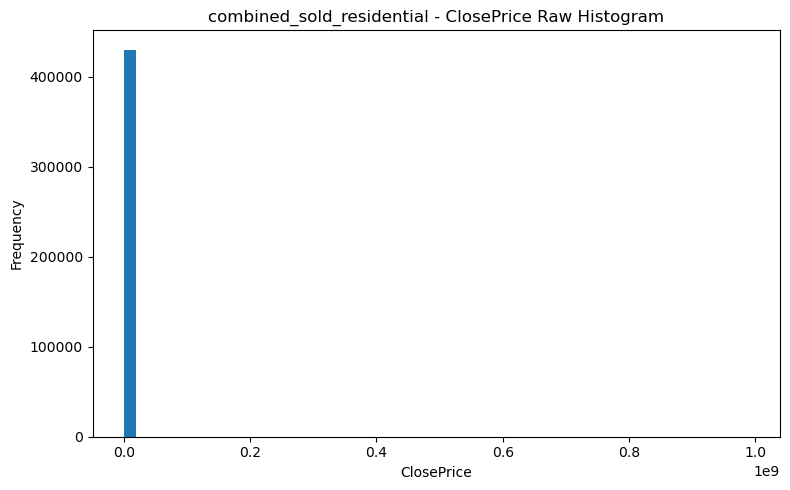

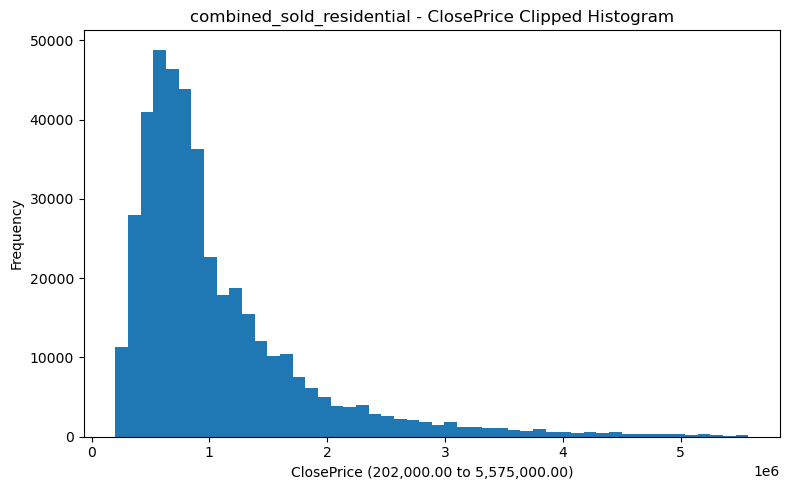

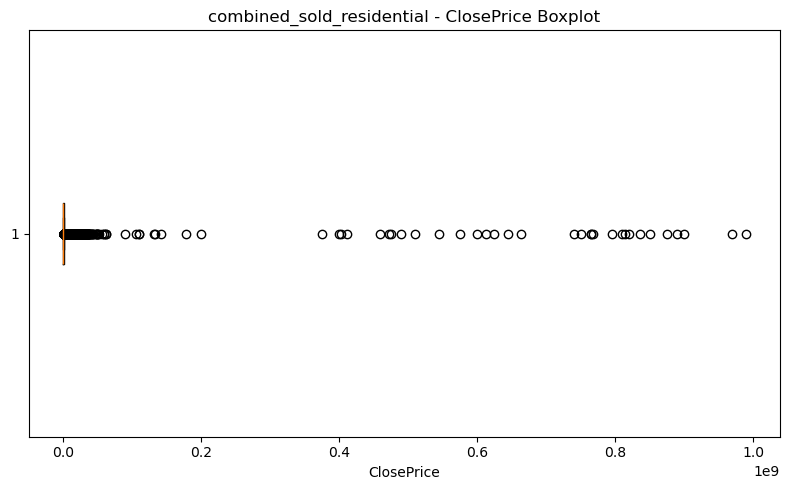

Creating continuous numeric charts for ListPrice


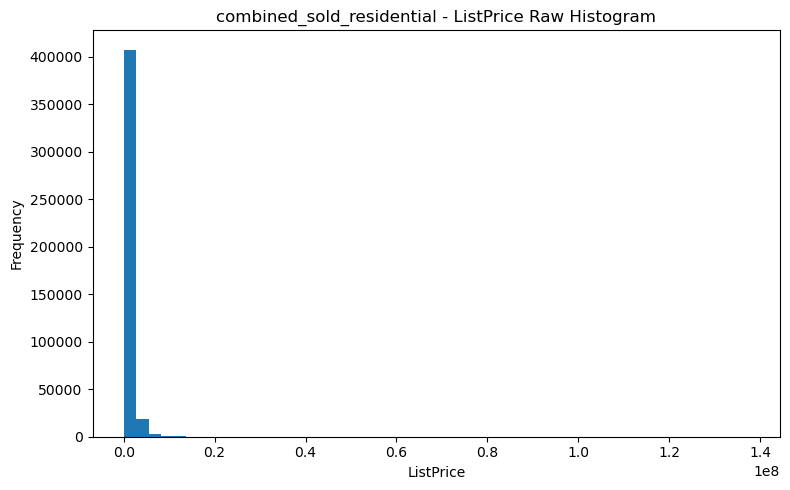

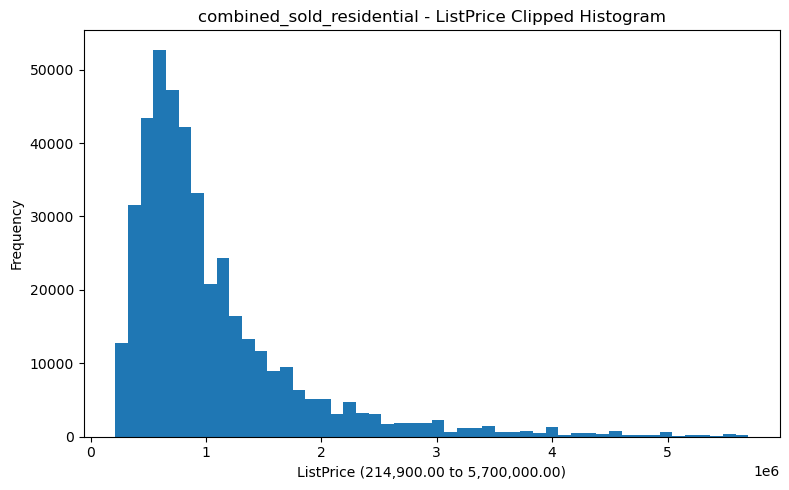

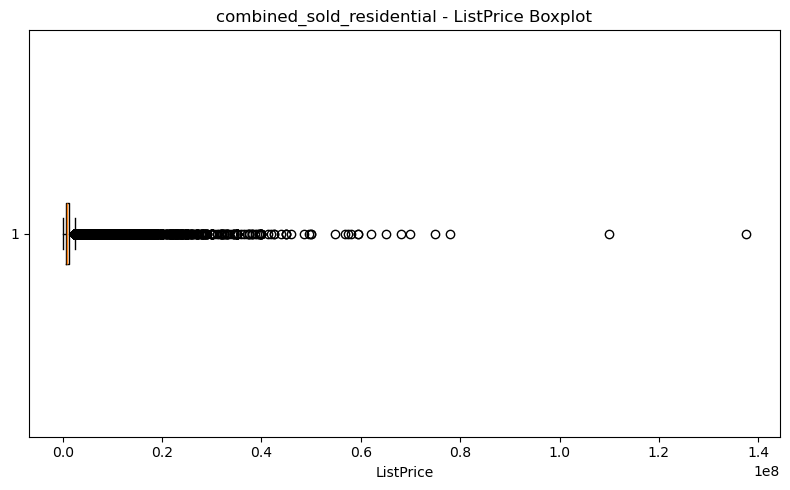

Creating continuous numeric charts for OriginalListPrice


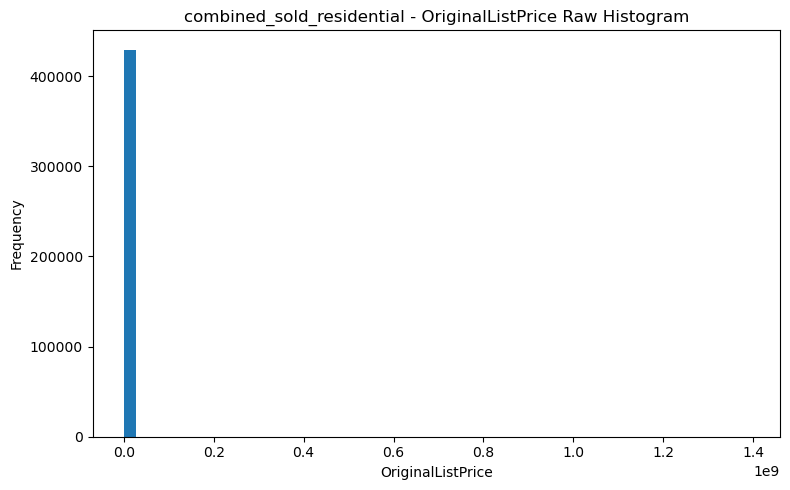

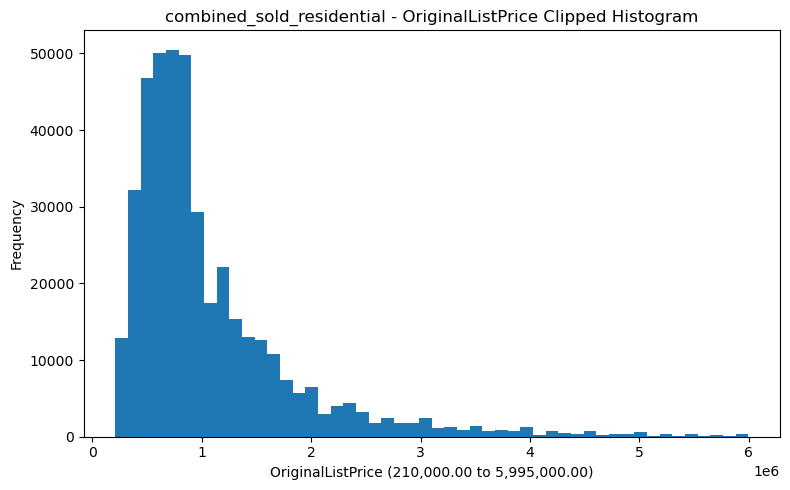

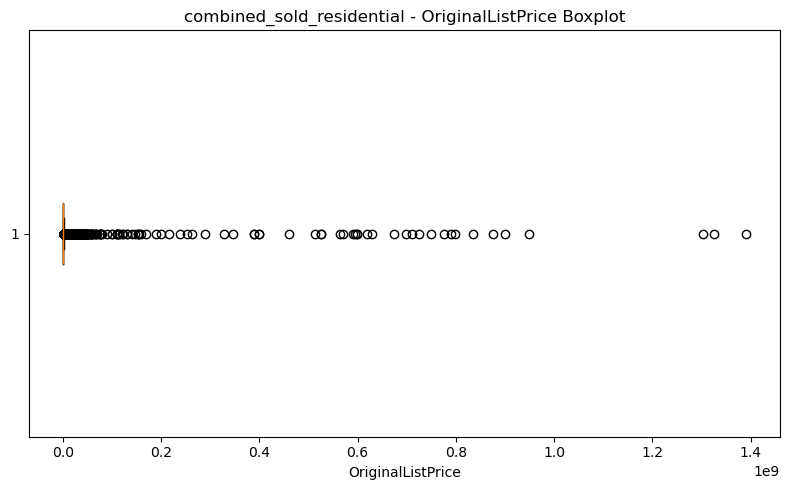

Creating DaysOnMarket charts


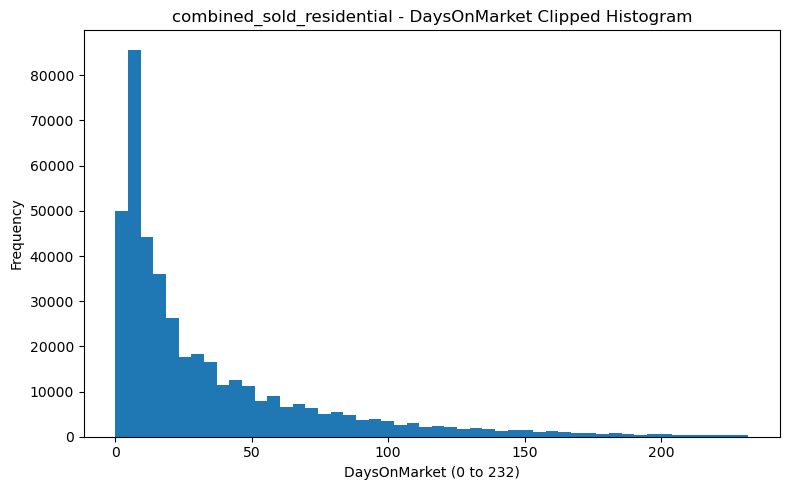

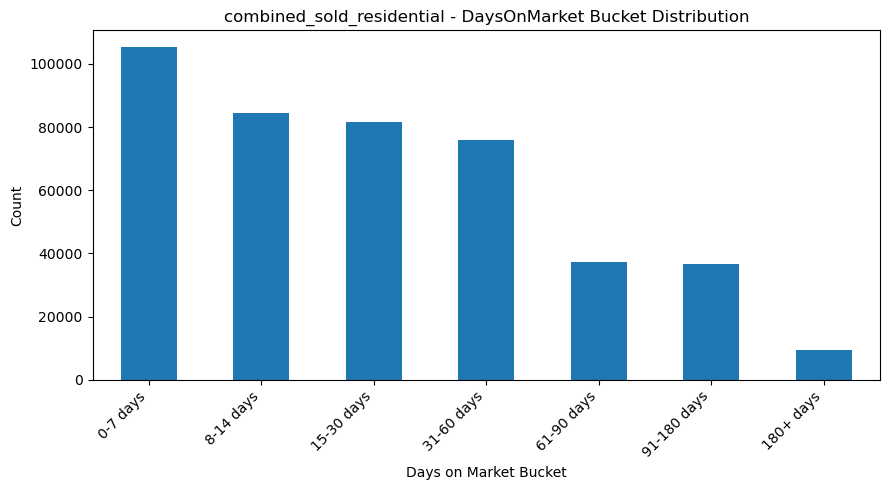

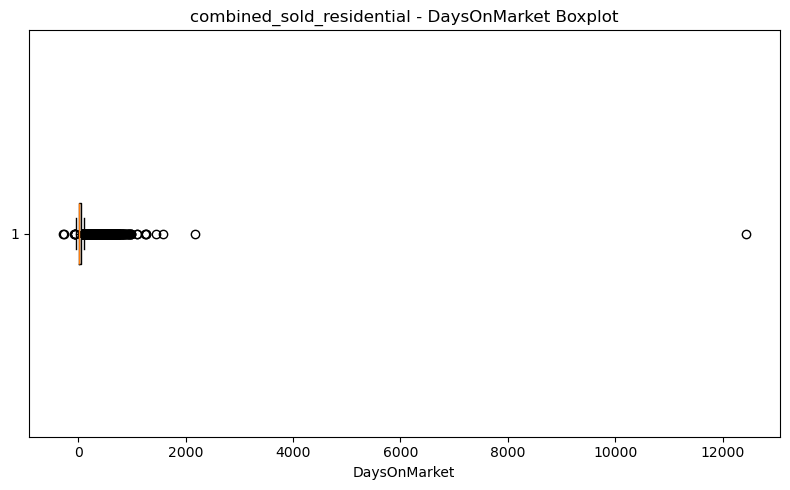

Creating continuous numeric charts for LivingArea


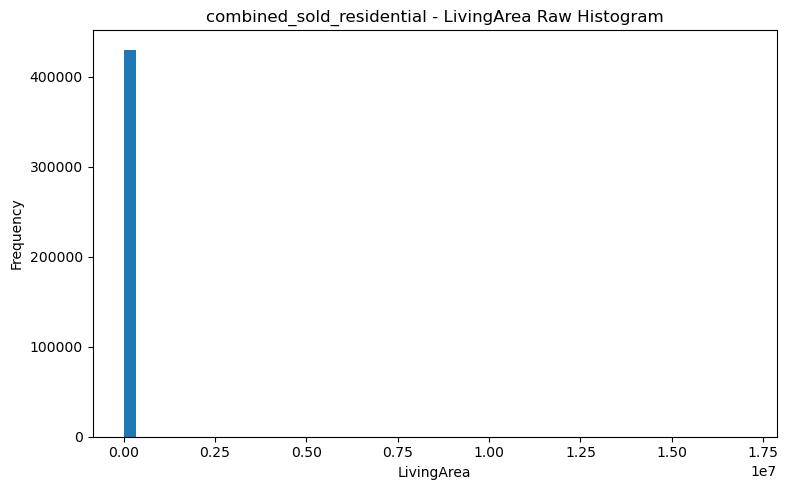

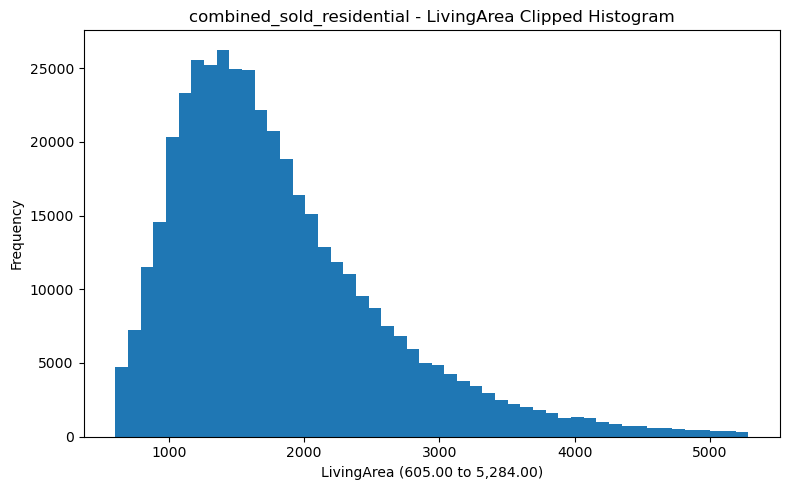

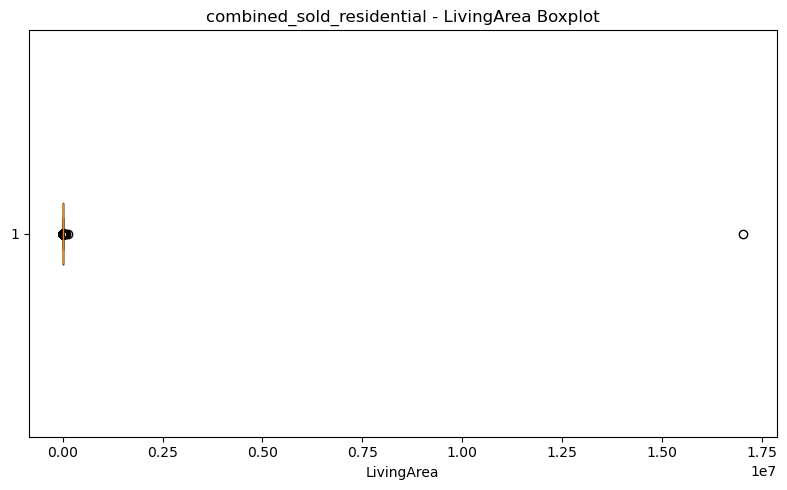

Creating continuous numeric charts for BuildingAreaTotal


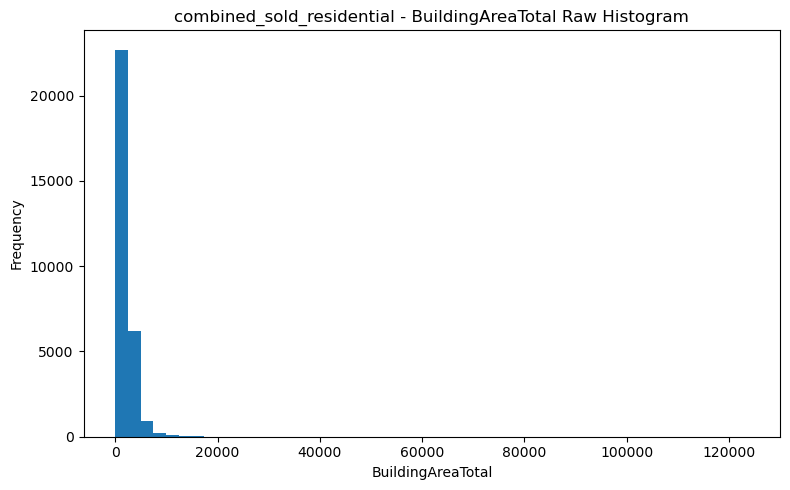

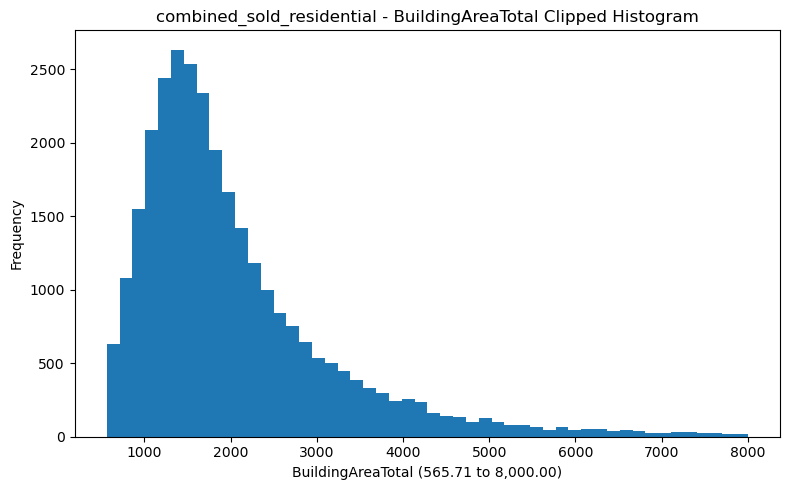

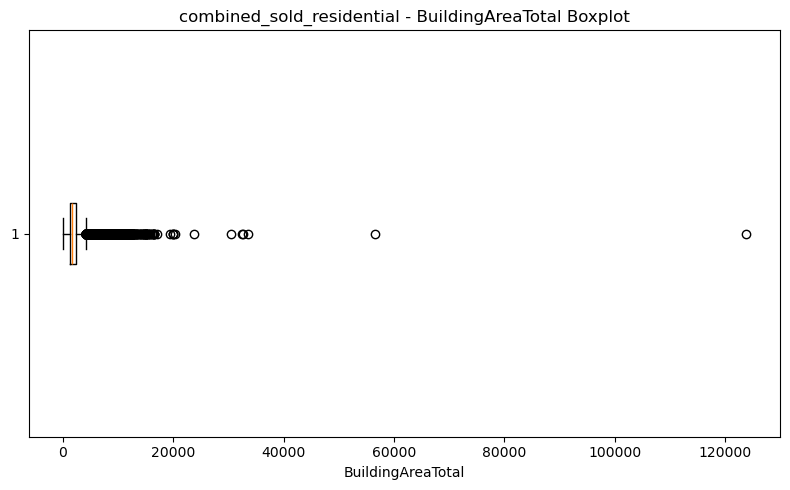

Creating continuous numeric charts for LotSizeSquareFeet


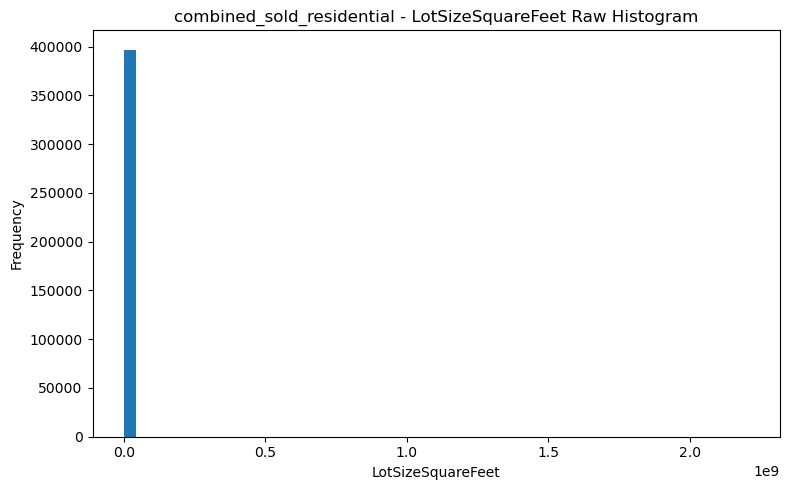

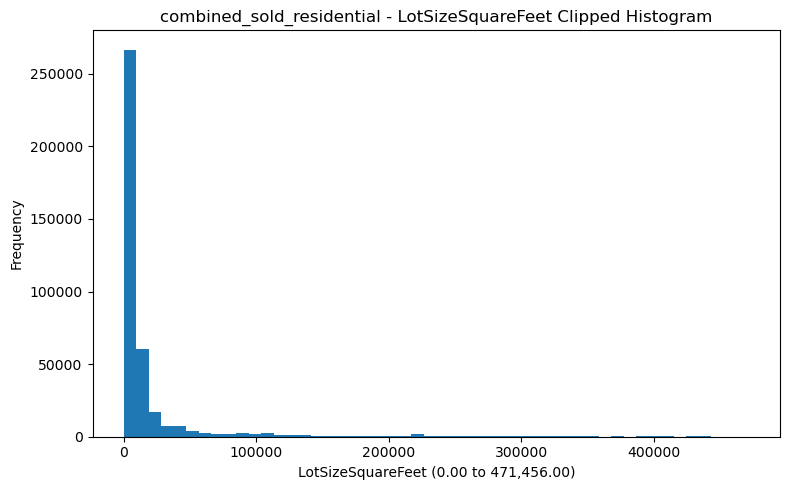

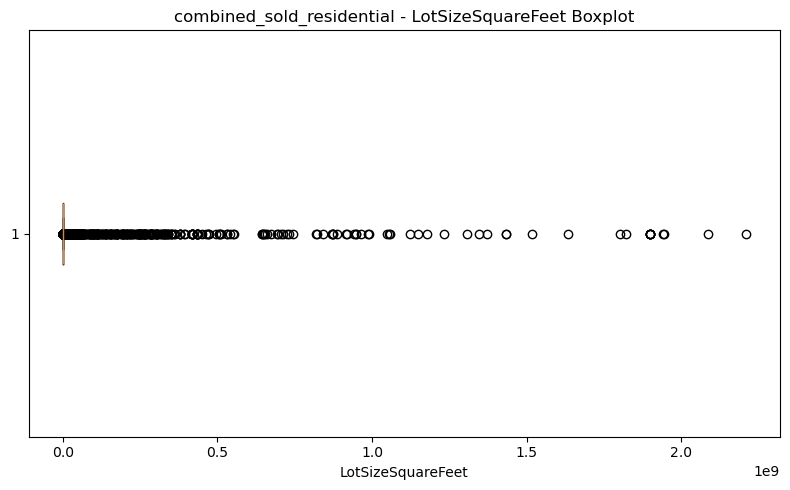

Creating continuous numeric charts for LotSizeAcres


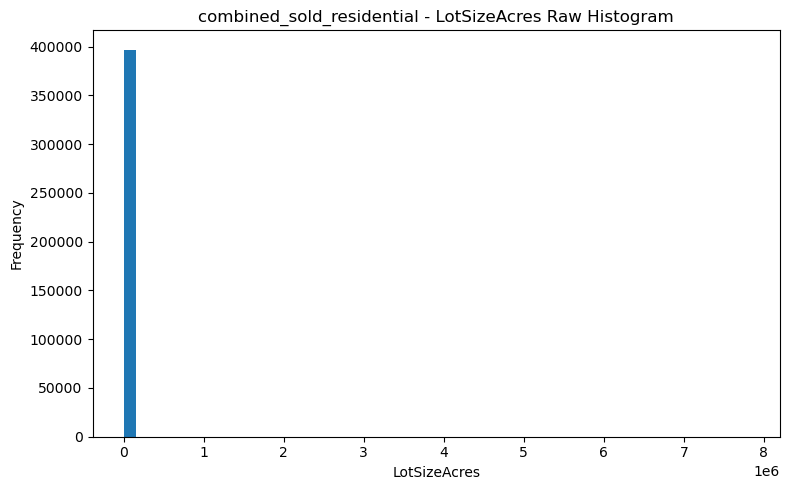

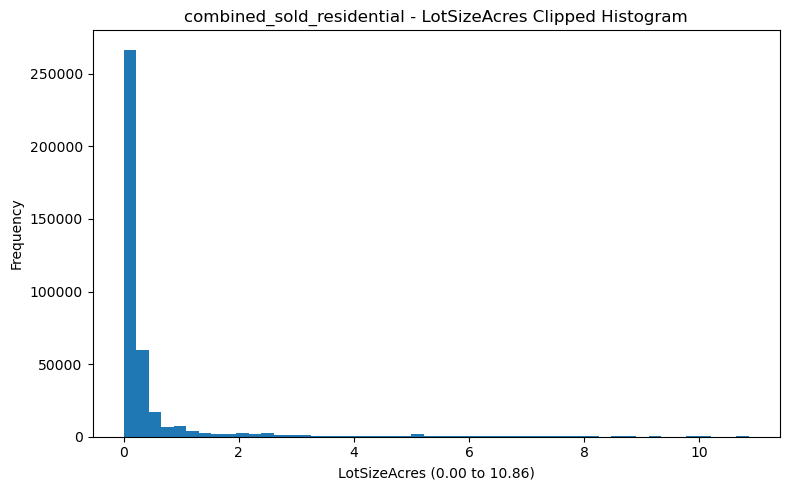

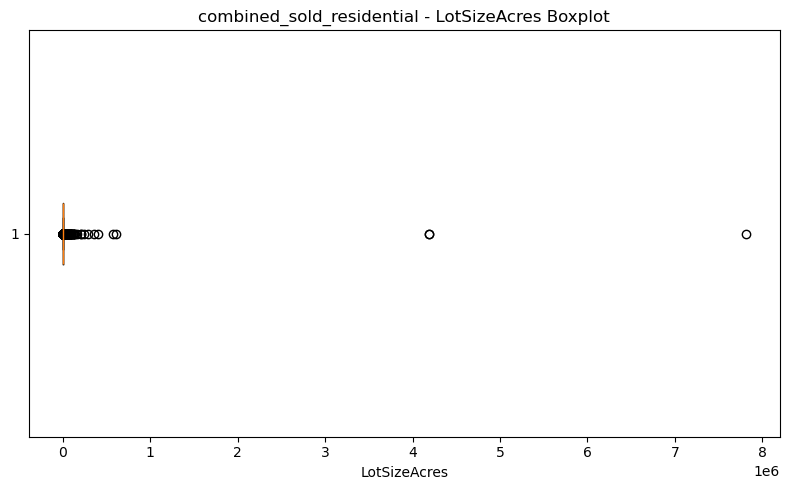

Creating discrete count charts for BedroomsTotal


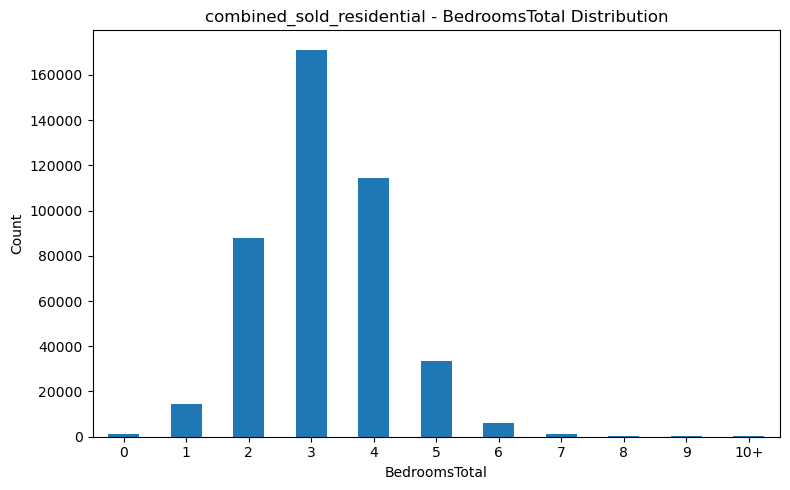

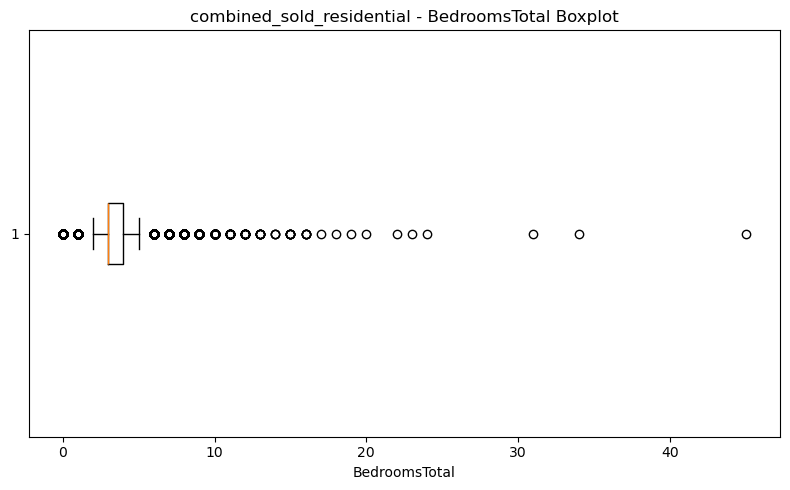

Creating discrete count charts for BathroomsTotalInteger


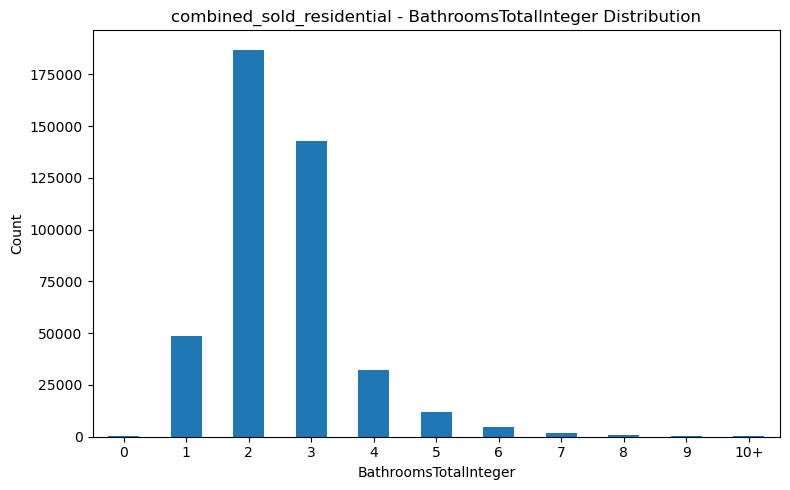

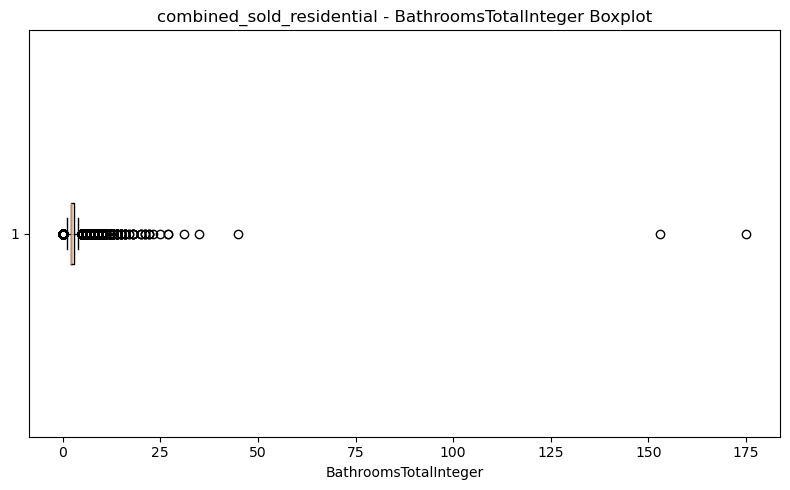

Creating continuous numeric charts for YearBuilt


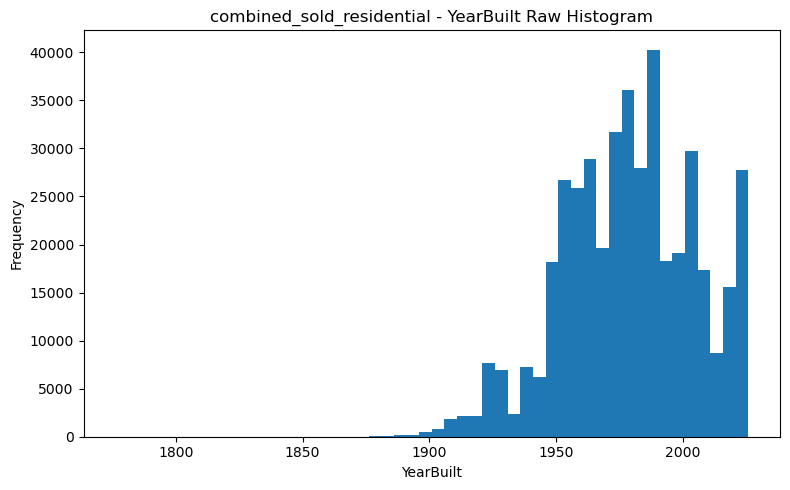

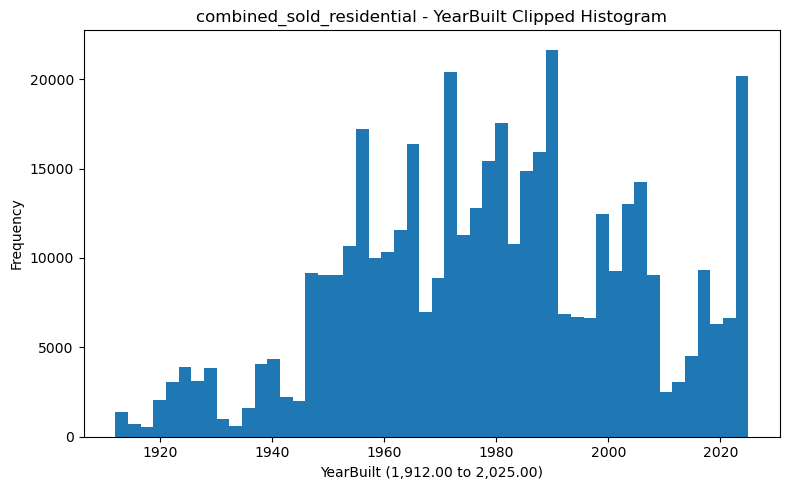

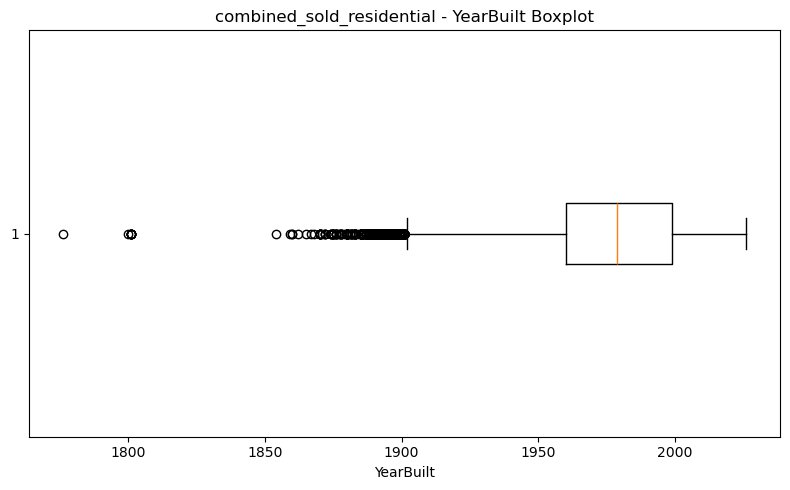

Charts saved to: eda_reports/charts

--------------------------------------------------------------------------------
combined_list_residential Numeric Charts
--------------------------------------------------------------------------------
Creating continuous numeric charts for ClosePrice


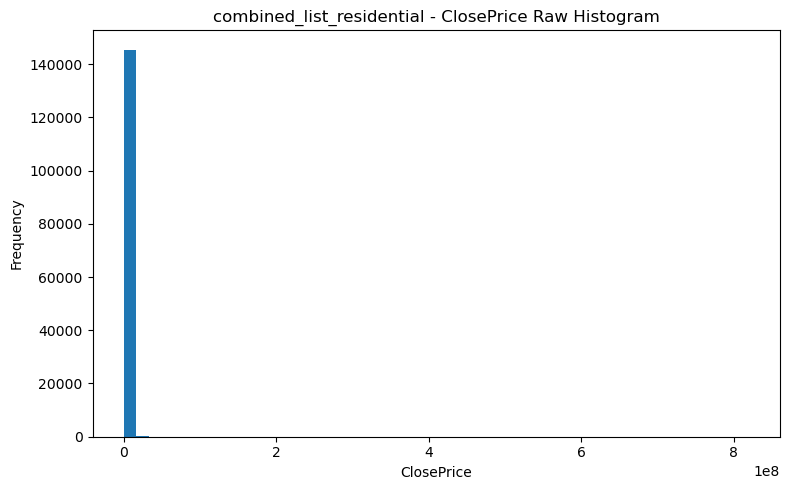

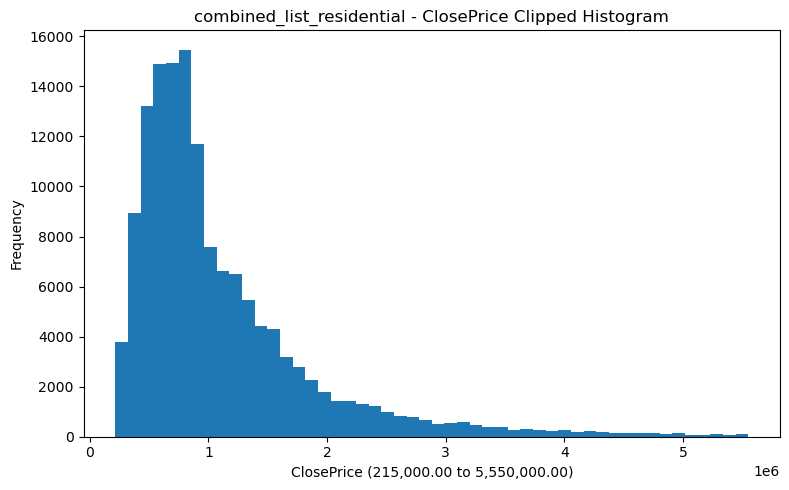

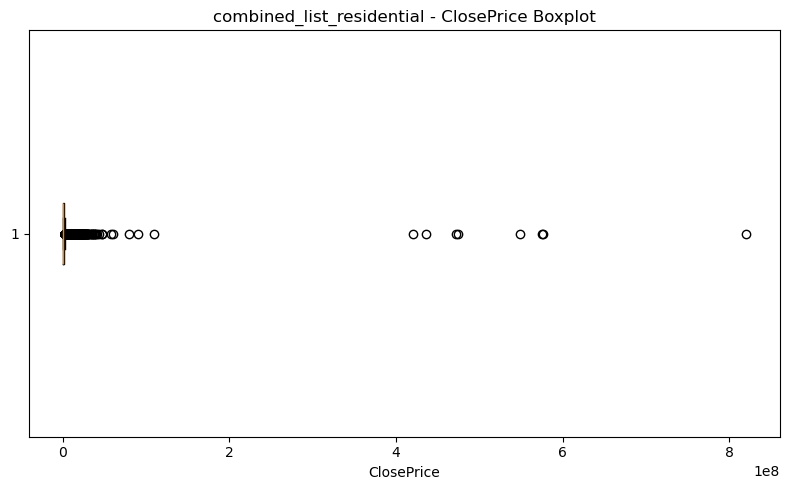

Creating continuous numeric charts for ListPrice


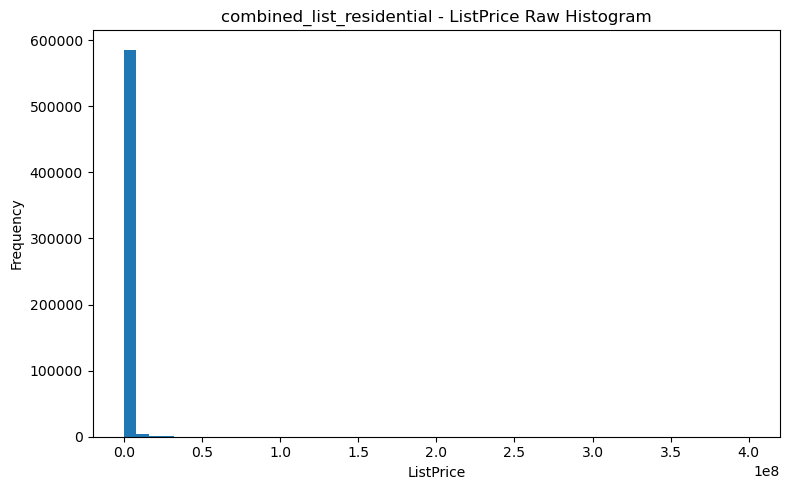

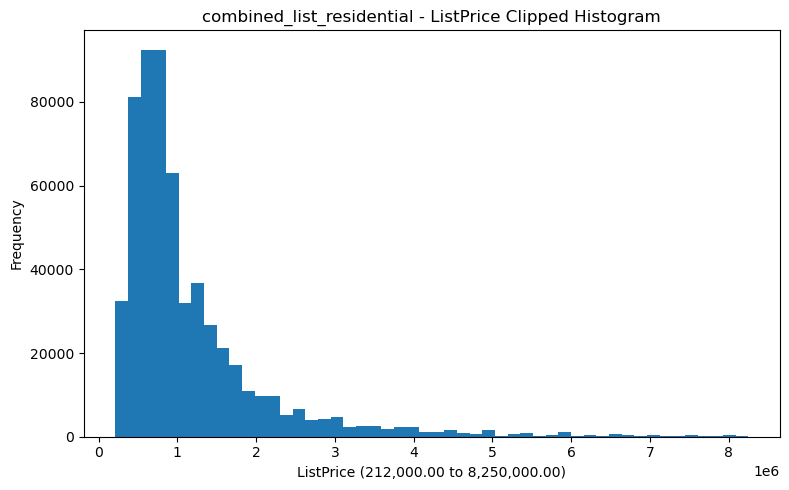

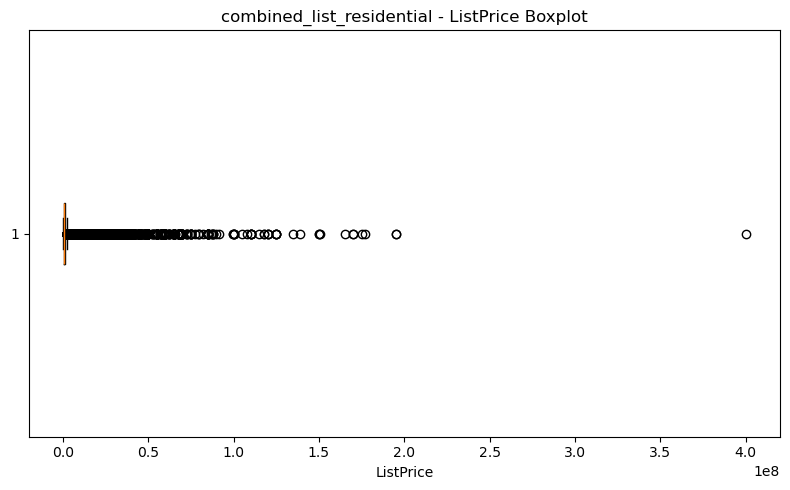

Creating continuous numeric charts for OriginalListPrice


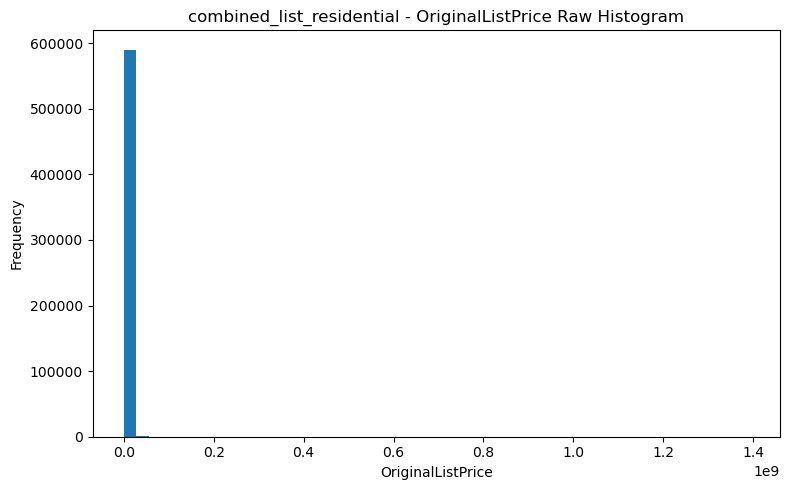

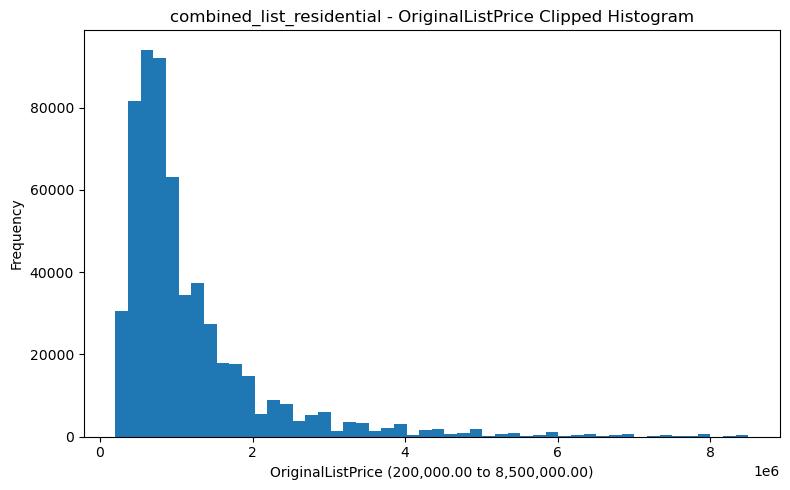

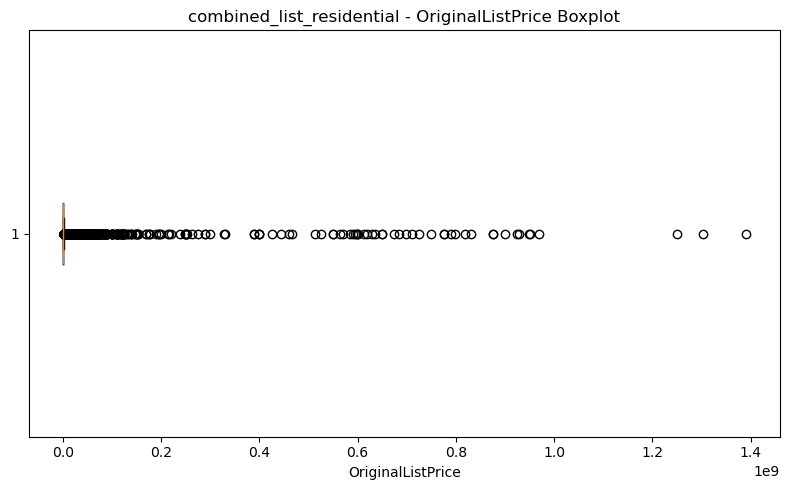

Creating DaysOnMarket charts


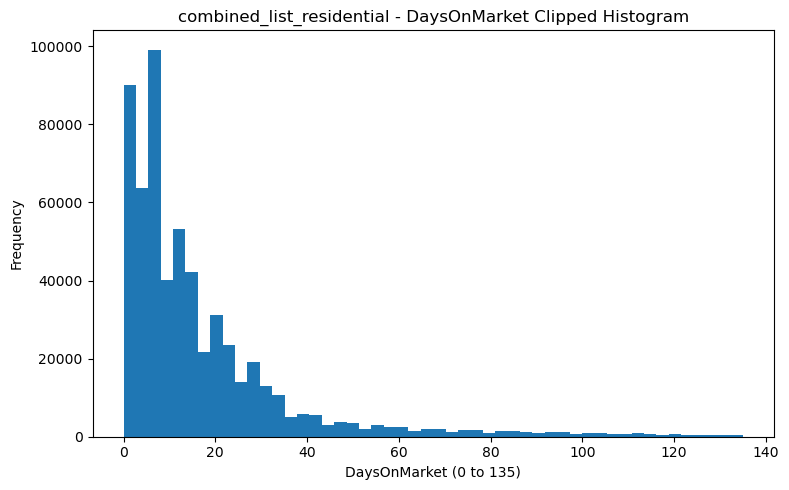

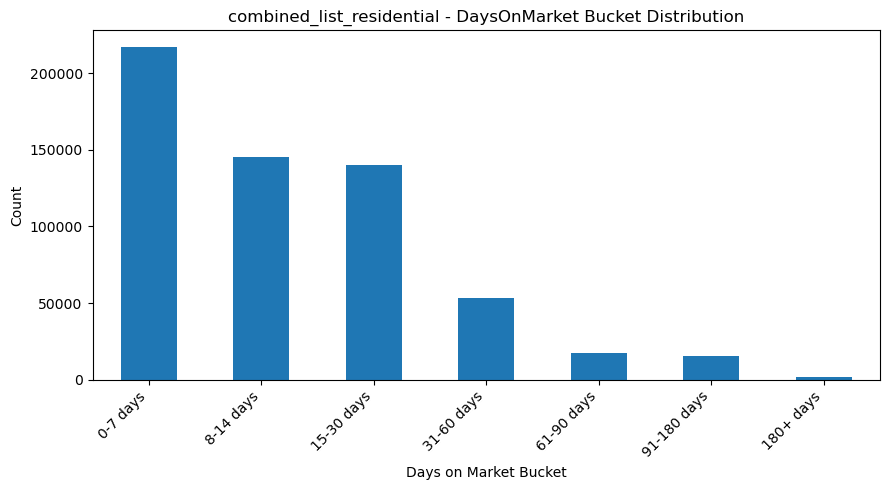

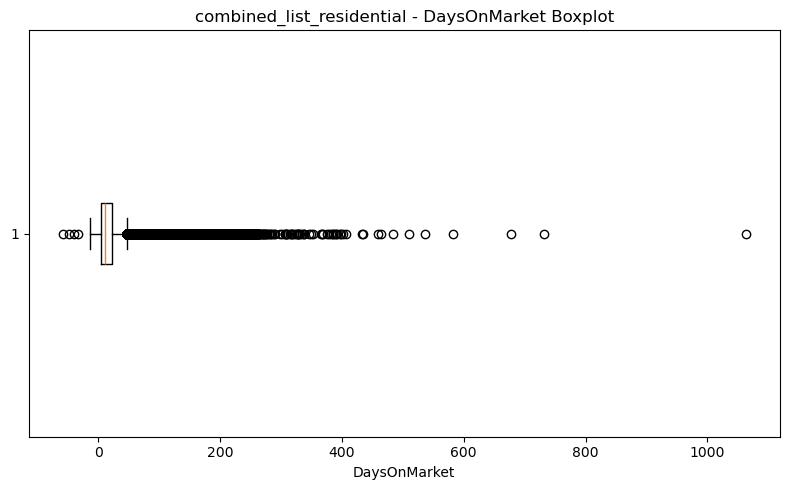

Creating continuous numeric charts for LivingArea


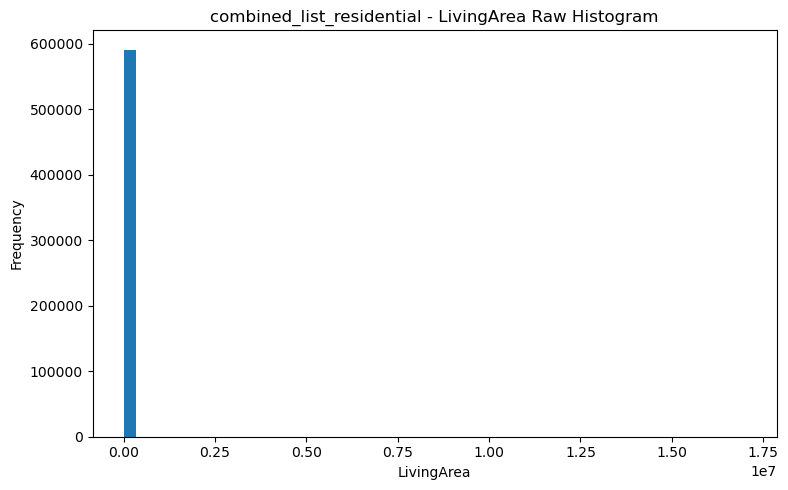

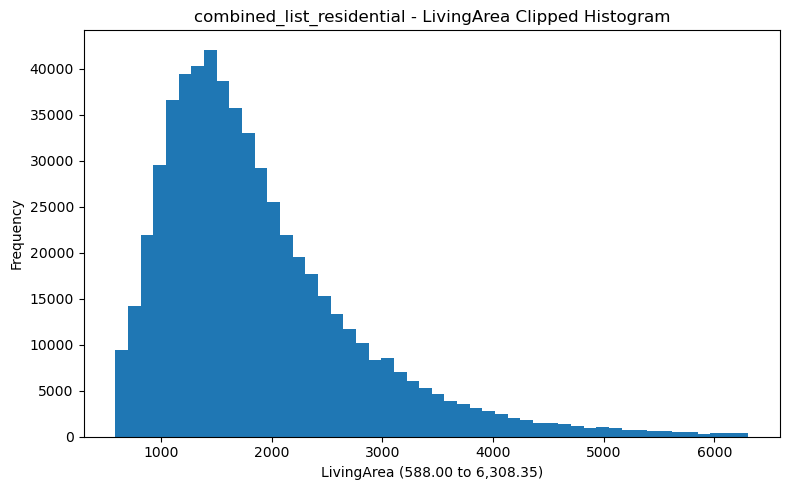

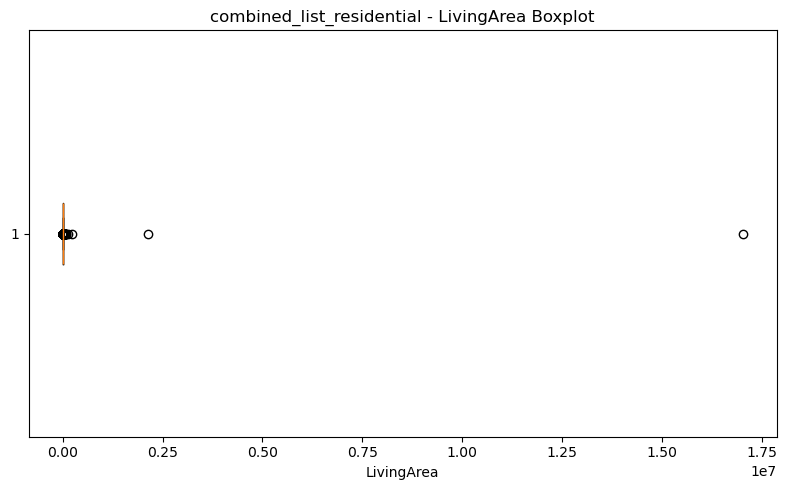

Creating continuous numeric charts for BuildingAreaTotal


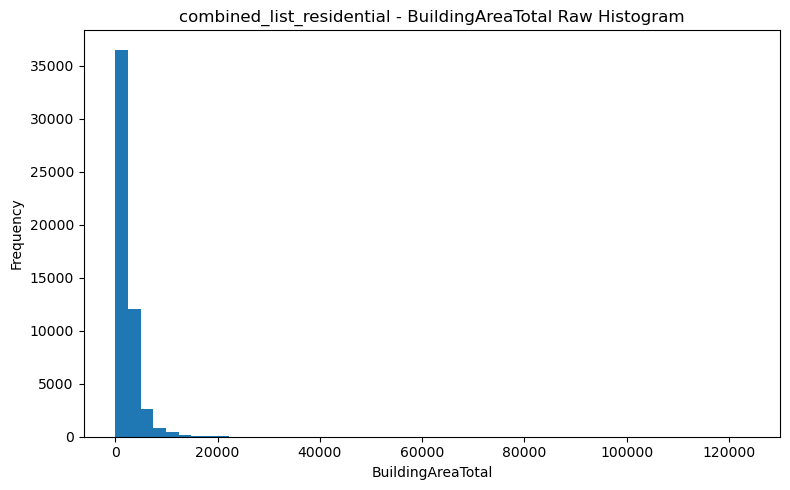

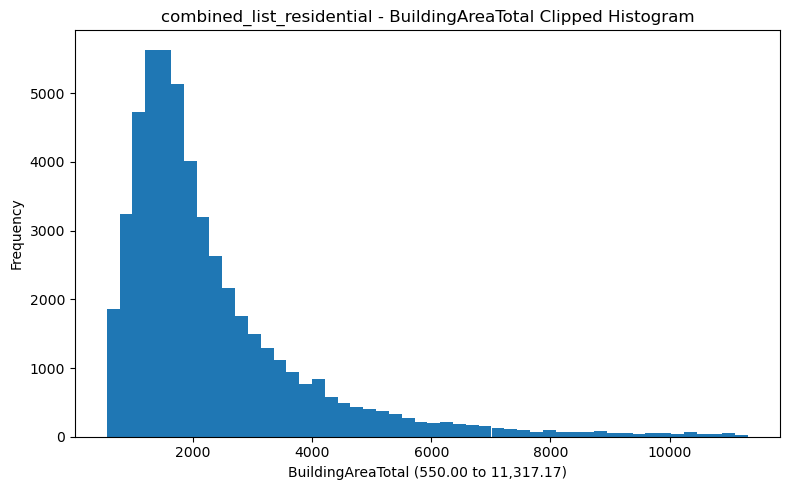

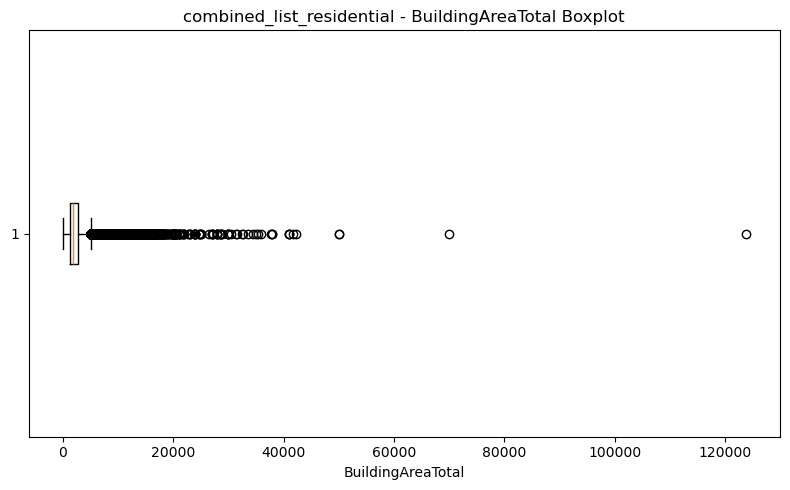

Creating continuous numeric charts for LotSizeSquareFeet


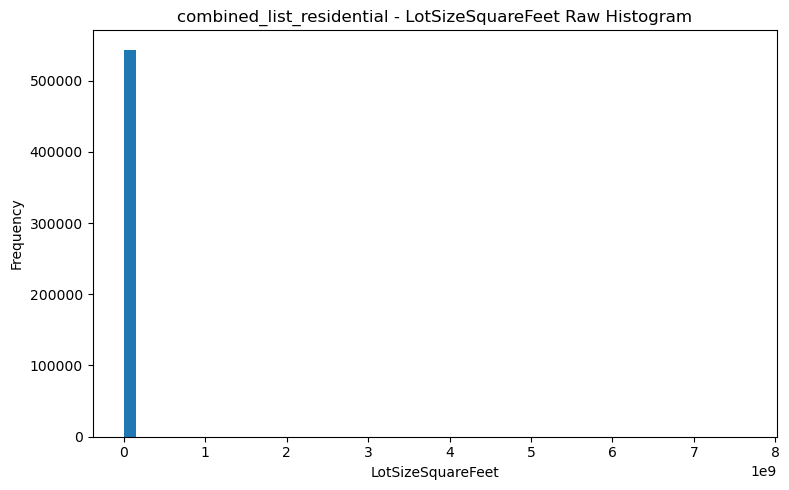

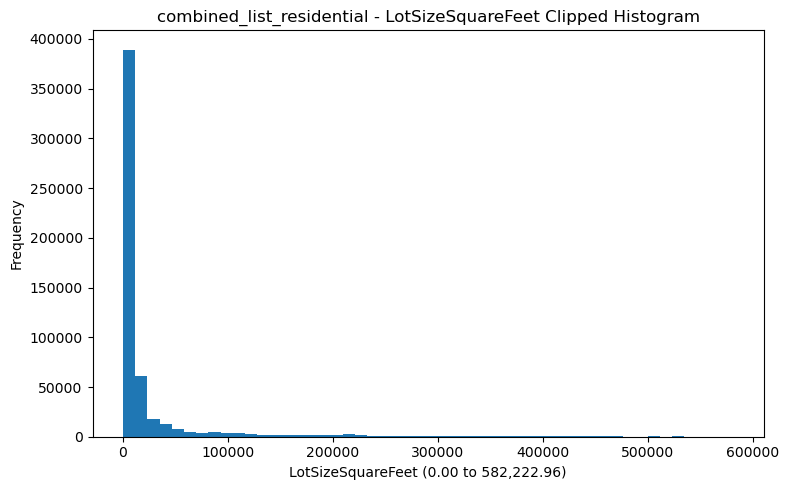

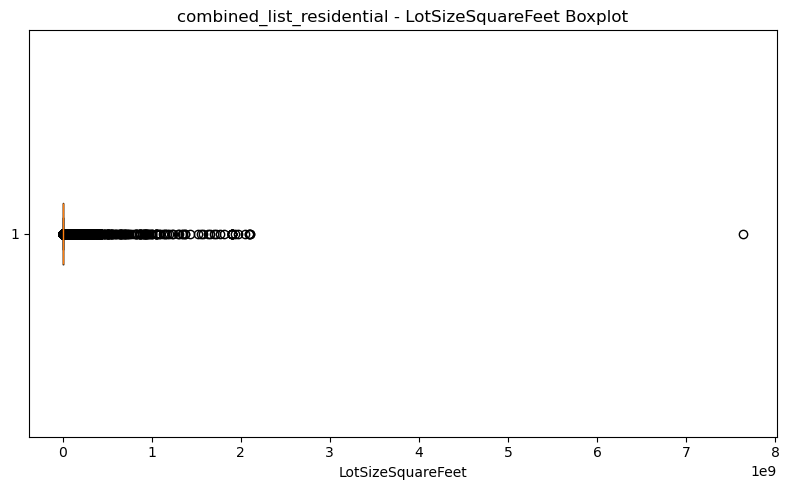

Creating continuous numeric charts for LotSizeAcres


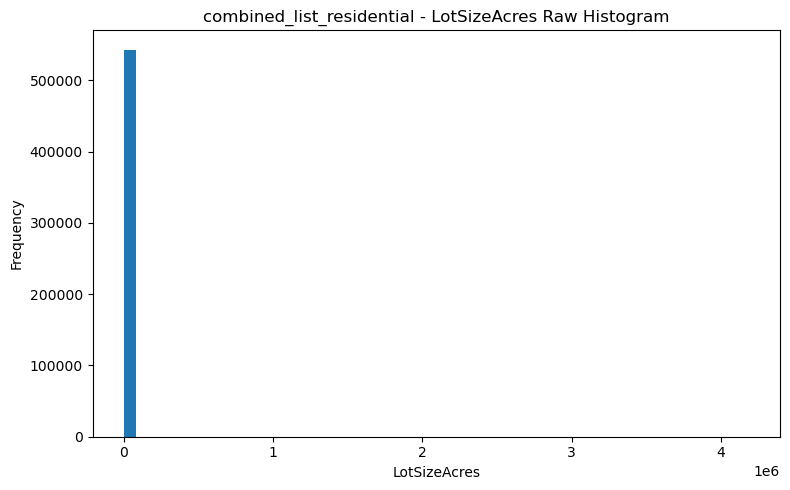

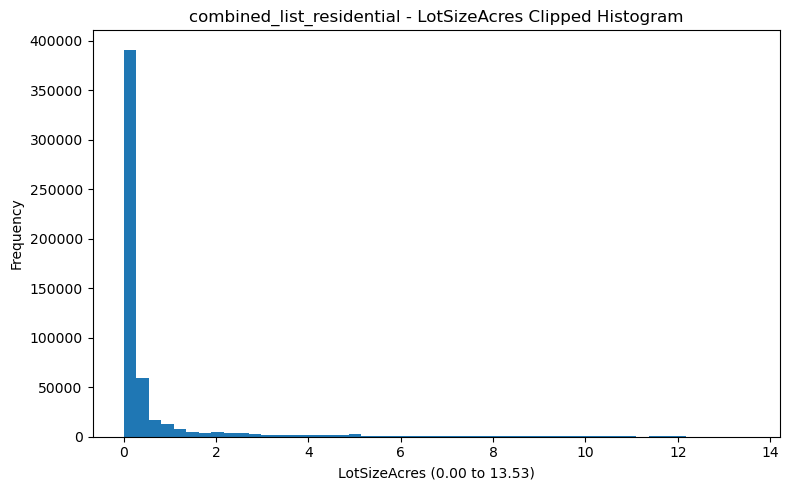

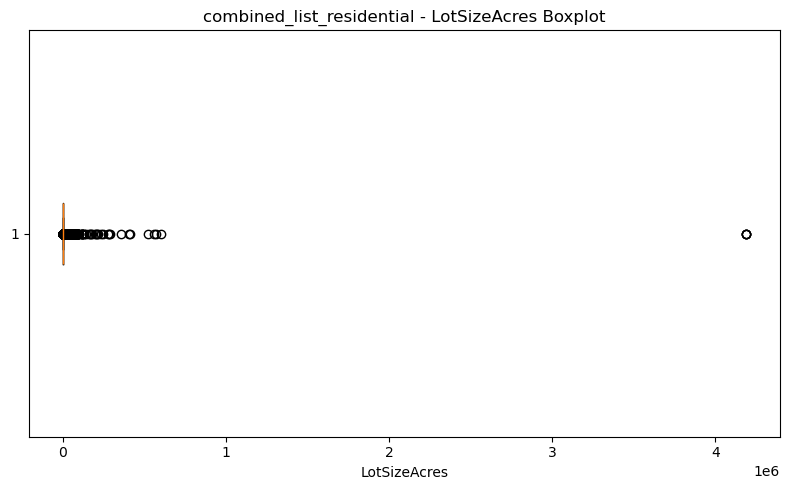

Creating discrete count charts for BedroomsTotal


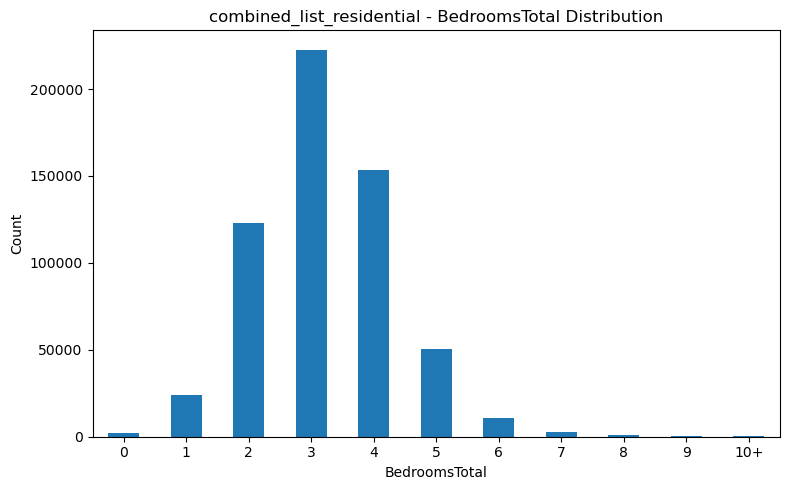

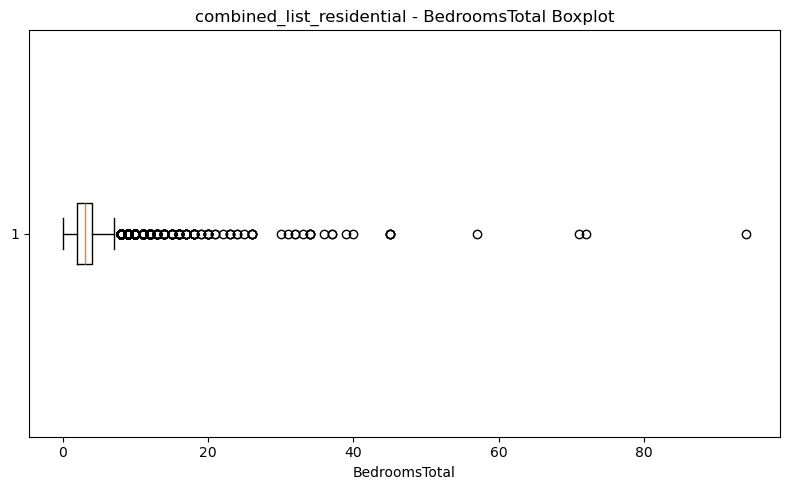

Creating discrete count charts for BathroomsTotalInteger


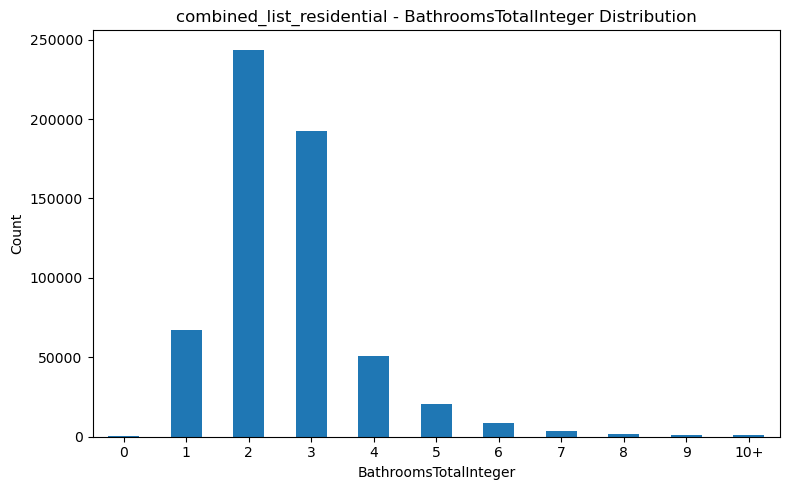

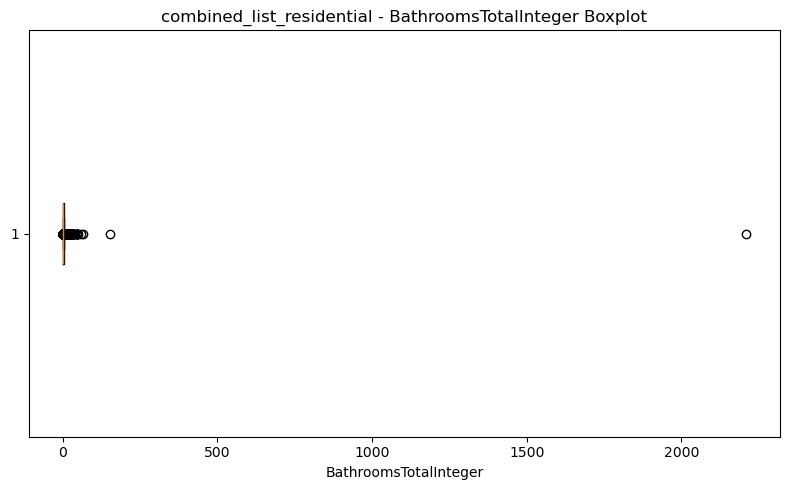

Creating continuous numeric charts for YearBuilt


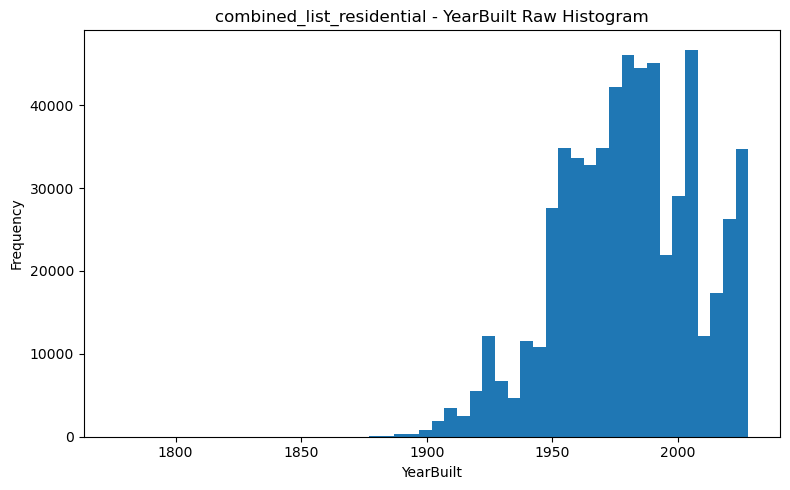

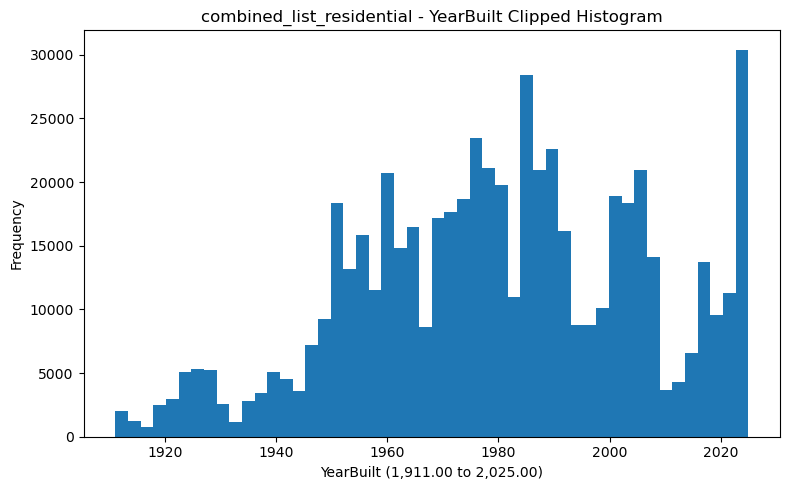

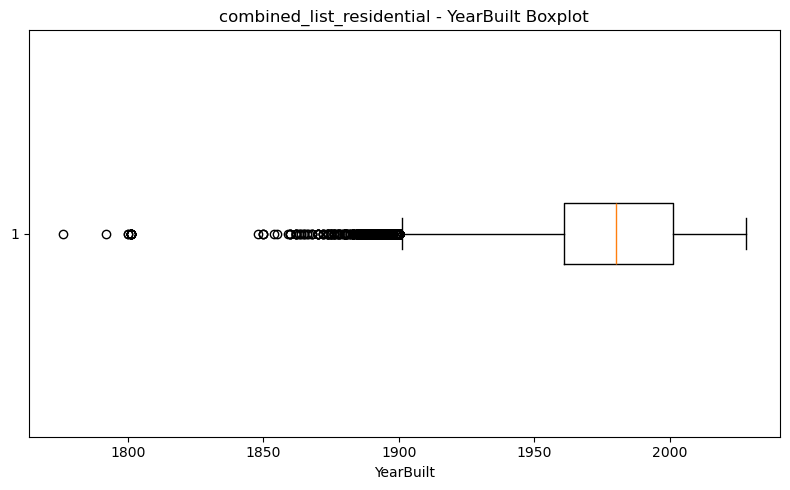

Charts saved to: eda_reports/charts


In [68]:
create_numeric_charts(
    combined_sold_residential,
    "combined_sold_residential",
    numeric_fields,
    show_plots=True
)

create_numeric_charts(
    combined_list_residential,
    "combined_list_residential",
    numeric_fields,
    show_plots=True
)

### 12. Answer suggested EDA questions

In [70]:
suggested_question_summary = answer_suggested_questions(
    combined_sold,
    combined_sold_residential
)


--------------------------------------------------------------------------------
Suggested EDA Questions
--------------------------------------------------------------------------------
Residential share in Sold data: 67.27%
Median ClosePrice: 825,000.00
Average ClosePrice: 1,193,113.20

Days on Market distribution:
count    430447.000000
mean         37.334443
std          53.669772
min        -288.000000
25%           8.000000
50%          18.000000
75%          48.000000
90%          94.000000
95%         132.000000
99%         232.000000
max       12430.000000

Sold above vs below list price:
                  count  percent
sale_vs_list                    
sold_below_list  183097    42.54
sold_above_list  172617    40.10
sold_at_list      74731    17.36

Date consistency check skipped because date columns were not found.

Top 10 counties by median ClosePrice:
                row_count  median_close_price  average_close_price
CountyOrParish                                         

### 13. Save final filtered datasets

In [72]:
print_section("Save Final Filtered Datasets")

combined_sold_residential.to_csv(
    REPORT_DIR / "final_combined_sold_residential_202401_202605.csv",
    index=False
)

combined_list_residential.to_csv(
    REPORT_DIR / "final_combined_list_residential_202401_202605.csv",
    index=False
)

print("EDA completed.")
print("Reports saved to:", REPORT_DIR)
print("Charts saved to:", CHART_DIR)


--------------------------------------------------------------------------------
Save Final Filtered Datasets
--------------------------------------------------------------------------------
EDA completed.
Reports saved to: eda_reports
Charts saved to: eda_reports/charts



--------------------------------------------------------------------------------
Suggested EDA Question Charts
--------------------------------------------------------------------------------


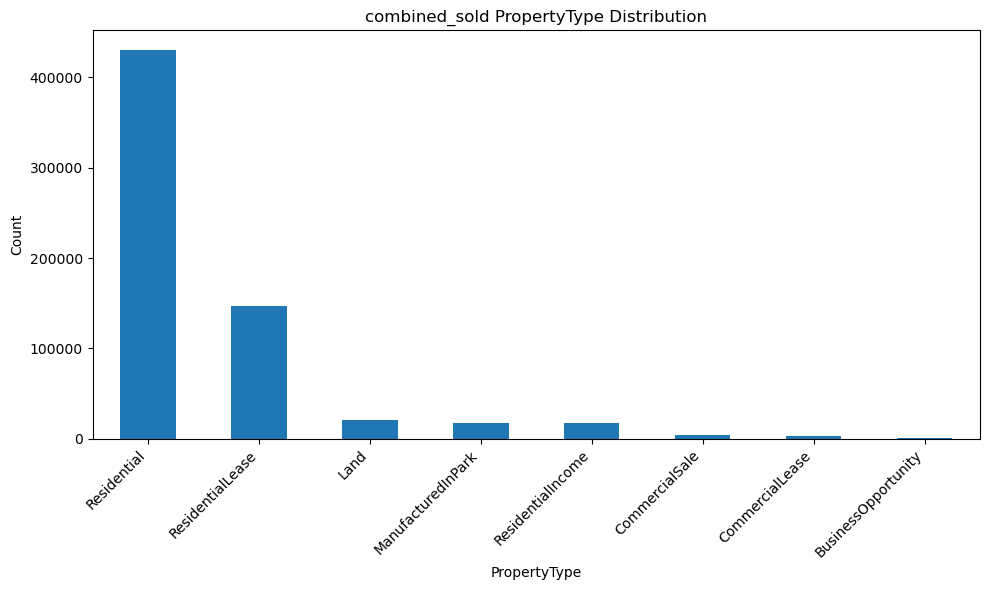

- combined_sold: Residential properties represent 67.27% of the full dataset.


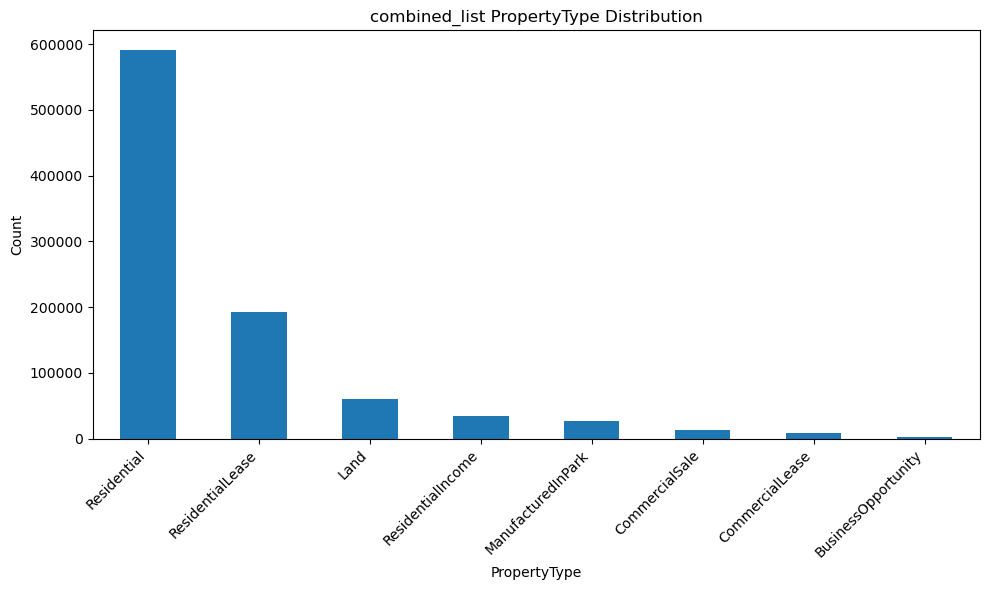

- combined_list: Residential properties represent 63.63% of the full dataset.


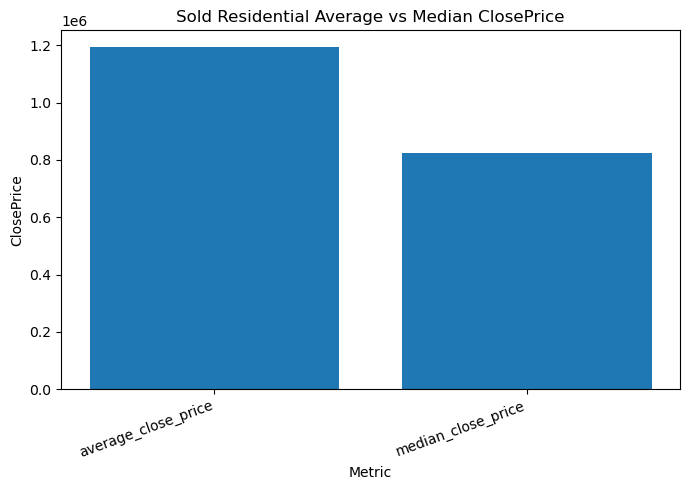

- The median Sold Residential ClosePrice is $825,000, and the average ClosePrice is $1,193,113.


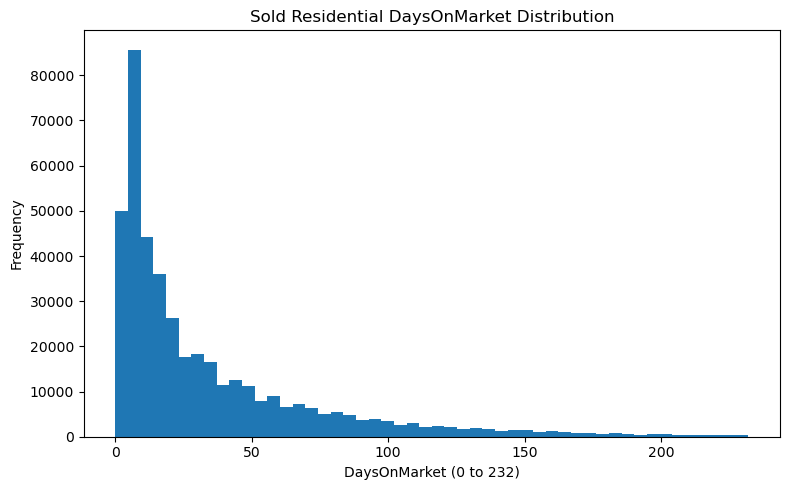

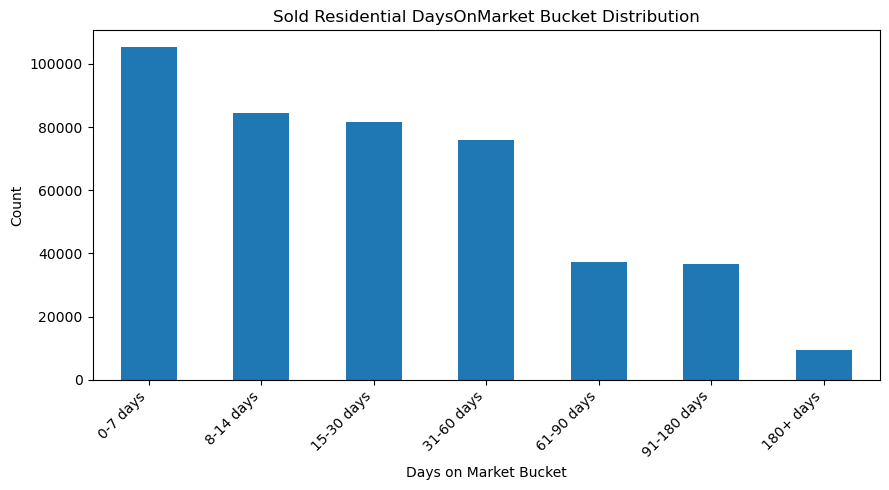

- The median DaysOnMarket is 18 days, and the 90th percentile is 94 days.


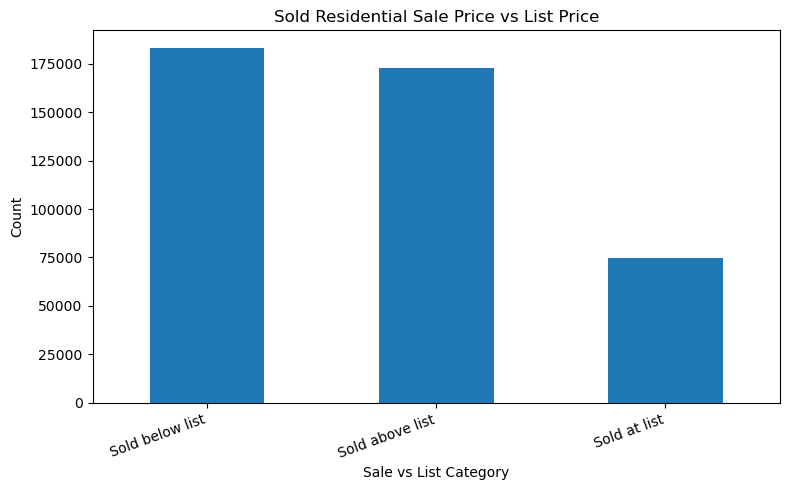

- Among Sold Residential records with valid prices, 40.10% sold above list price, 42.54% sold below list price, and 17.36% sold at list price.
- Date consistency chart was skipped because suitable list date and close date columns were not found.


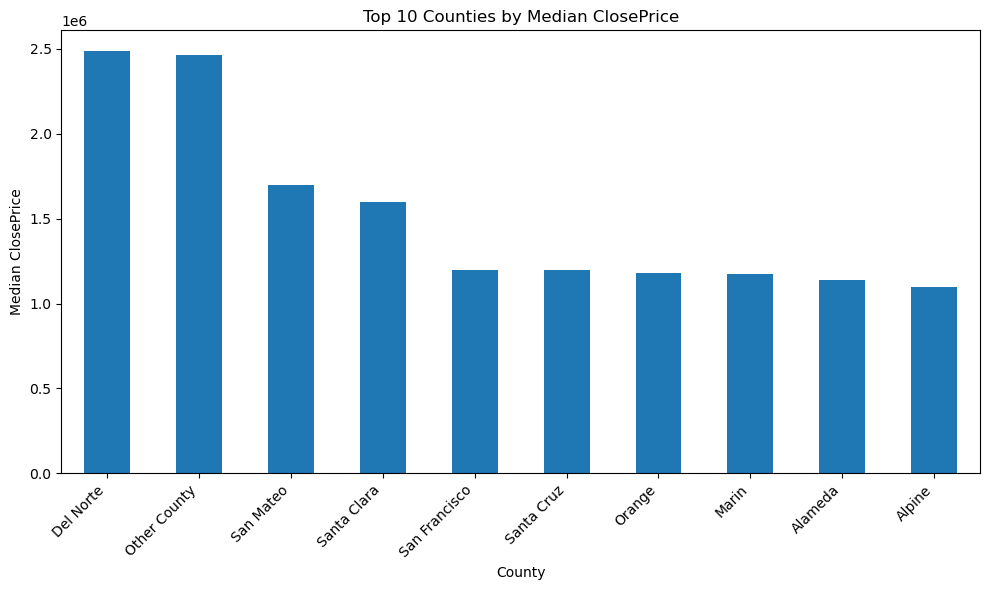

- Del Norte has the highest median ClosePrice among counties, with a median of $2,485,000.

Suggested EDA question charts completed.
Charts saved to: eda_reports/charts
Summary notes saved to:
eda_reports/suggested_eda_question_analysis_notes.csv


In [73]:
_ = create_suggested_eda_question_charts(
    combined_sold=combined_sold,                    # full data, only for PropertyType share
    combined_list=combined_list,                    # full data, only for PropertyType share
    combined_sold_residential=combined_sold_residential,  # main EDA
    show_plots=True
);